In [2]:
import torch
from torch import nn, Tensor
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
import numpy as np  
from flow_matching.solver import ODESolver
from torch.utils.data import TensorDataset, DataLoader
import time
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
import torch.optim as optim
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import seaborn as sns

import sys
sys.path.append('./Textual-Anomaly-Detection-Framework/Anomaly Detection Framework')
from Data_Preparation import utils
import Modelisation.evaluation as ev
from utils import load_data_inlier, load_data_test, load_hyperparams
from utils import save_results
from Modelisation.FlowMatching.flow_matching_transformers import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

%load_ext autoreload
%autoreload 2

2026-02-26 14:46:29.255142: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Device: cuda


## Model

In [ ]:
class FlowMatching(nn.Module):
    def __init__(self, source, target, input_dim=64, latent_dim=256, device='cuda', seed=42):
        super().__init__()
        
        self.seed = seed
        self.target = target
        self.source = source
        self.device = device
            
        if self.source == 'target-noised':
            noise = torch.randn(self.target.shape[0], self.target.shape[1])
            self.target_noised = self.target + noise
            
        if self.source == 'point-mean':
            self.point_mean = self.target.mean(dim=0).to(self.device)            
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.expand(x.shape[0], 1)            
        xt = torch.cat([x, t], dim=1)

        return self.net(xt)
    
    def sampling_source(self, n_samples):

        
        if self.source == 'gaussian':
            return torch.randn(n_samples, self.input_dim).to(self.device)
    
        if self.source == 'circle': return Tensor(make_circles(n_samples=n_samples, noise=0.05, factor=0.95)[0]).to(self.device)
    
        if self.source == 'poisson': return Tensor(np.random.poisson(5, (n_samples, self.input_dim))).to(self.device)
    
        if self.source == 'uniform': return Tensor(np.random.uniform(low=self.target.min(), high=self.target.max(), size=(n_samples, self.input_dim))).to(self.device)
    
        if self.source == 'sphere':
            
            z = torch.randn(n_samples, self.input_dim)
            return Tensor(z / z.norm(dim=1, keepdim=True)).to(self.device)
        
        if self.source == 'sphere-noised':
            z = torch.randn(n_samples, self.input_dim)
                   
            z = z / z.norm(dim=1, keepdim=True)
            noise = torch.randn_like(z) * 0.25
            return Tensor(z + noise).to(self.device)
        
        if self.source == 'point-mean':
            # return self.point_mean.repeat(n_samples).reshape(-1,self.input_dim)
            return Tensor(np.array([0, 0]).repeat(n_samples).reshape(-1,self.input_dim)).to(self.device)
            
        
    def interpolation(self, n_samples, x1=None):

        # source sampling
        x0 = self.sampling_source(n_samples)
        # target sampling ( get n_samples examples from the all target dataset )
        # replace --> avec ou sans remise
        if x1 is None : idx = np.random.choice(self.target.shape[0], n_samples, replace=True)
        
        if self.source == 'target-noised':
            noise = torch.randn(x1.shape[0], x1.shape[1]).to(self.device)
            x0 = x1 + noise
        
        if x1 is None : x1 = self.target[idx].to(self.device)

        # sampling the time between 0 ad 1
        t = torch.rand(n_samples, 1).to(self.device)
        # t = torch.rand(n_samples).to(self.device)

        xt = (1 - t) * x0 + t * x1
        ut = x1 - x0
        
        return xt, t, ut

## Trainer

In [ ]:
class FlowMatchingTrainer():
    def __init__(self, flow_model,  verbose=True):

        self.flow_model = flow_model
        self.verbose = verbose

    def train(self, dataloader, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam'):
        
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(self.flow_model.parameters(), lr=lr, weight_decay=weight_decay)

        for s in range(n_epochs):

            for data, in dataloader:

                xt, t, ut = self.flow_model.interpolation(data.shape[0], data)
                vt =  self.flow_model(xt, t)

                optimizer.zero_grad()

                loss = loss_fn(vt, ut)
                loss.backward()

                optimizer.step()
            
            if self.verbose and s % (n_epochs // 5) == 0:
                print(f" step {s} -> loss : {loss.item():.5f}")
                
        return self.flow_model

    def forward_flow(self, x_0, solver_type='midpoint', n_steps=10):
            
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target

    def backward_flow(self,x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source
    
    def forward_backward_flow(self, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_inter_target_to_source[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target_recons


    def test(self, X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10):

        if score_type == 'norm':
            x_source_after_backward = self.backward_flow(X_test, solver_type, n_steps)[-1].cpu().detach()
            # scores = ((x_source_after_backward - self.flow_model.target_centroid) ** 2).sum(dim=1)
            scores = (x_source_after_backward ** 2).sum(dim=1)

        if score_type == 'recons':
            x_target_after_forward_backward = self.forward_backward_flow(X_test, solver_type, n_steps)[-1]
            scores = ((torch.norm(x_target_after_forward_backward - X_test, dim=1)** 2)).cpu().detach()
 
        # auc = roc_auc_score(y_test, scores)
        # ap = average_precision_score(y_test, scores)
        # fpr, tpr, thresholds = roc_curve(y_test, scores)
        # idx = np.where(tpr >= 0.95)[0][0]
        # fpr95 = fpr[idx]

        auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)

        print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  

        return auc, fpr95, ap 

## Data

In [3]:
inlier_topic = 'computer'
dataset_name = '20newsgroups'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 6

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

print(data_train)
print(data_test)

X_inlier = Tensor(data_train['sbert_embeddings']).to(device)
X_test =  Tensor(data_test['sbert_embeddings']).to(device)
y_test = np.array(data_test['anomaly_class'])

Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 2576
})
Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 1909
})


## Run

In [ ]:
batch_size = 64
X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

input_dim = X_inlier.shape[1]
latent_dim = 256
lr = 1e-5
weight_decay = 1e-5
n_epochs = 1000

target = X_inlier.cpu()
source = 'target-noised'

flow_model = FlowMatching(source, target, input_dim, latent_dim, device).to(device)
optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.MSELoss()

fm_trainer = FlowMatchingTrainer(flow_model, verbose=True)

flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='recons', solver_type='midpoint', n_steps=10)


In [ ]:
# x_inter_target_to_source = fm_trainer.backward_flow(X_test)[-1]
# scores = (x_inter_target_to_source ** 2).sum(dim=1)

In [ ]:
# x_inter_target_to_source_inlier = x_inter_target_to_source[:, y_test == 0, :]
# x_inter_target_to_source_inlier.shape
# x_inter_target_to_source_anomaly = x_inter_target_to_source[:, y_test == 1, :]
# x_inter_target_to_source_anomaly.shape

## Toy Example

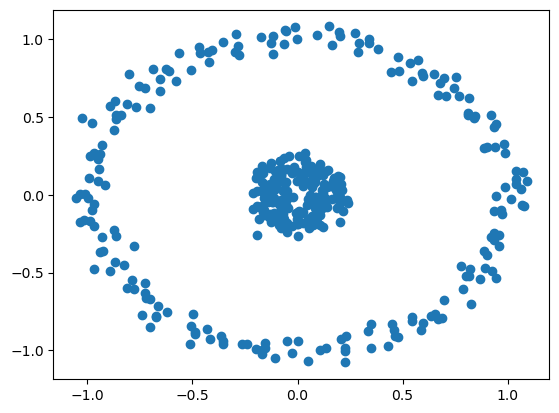

In [5]:
# a = np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])
a = np.concatenate([make_circles(400, noise=0.05, factor=0.15)[0] , torch.randn(0, 2)])
plt.scatter(a[:,0], a[:,1])

In [6]:
batch_size = 256
# X_train = TensorDataset(Tensor(np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])).to(device))
# X_train = TensorDataset(Tensor(make_moons(256, noise=0.05)[0]).to(device))
X_train = Tensor(make_circles(noise=0.05, factor=0.15)[0]).to(device)
# X_train = Tensor(np.array([0, 0]).repeat(300).reshape(-1,2)).to(device)
# X_train = Tensor(torch.randn(300, 2)).to(device)
X_inlier_dl = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)

input_dim = 2
latent_dim = 64
lr = 1e-2
weight_decay = 0
n_epochs = 10000

target = X_train.cpu()
source = 'gaussian'

flow_model = FlowMatching(source, target, input_dim, latent_dim, device).to(device)
optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.MSELoss()

fm_trainer = FlowMatchingTrainer(flow_model, verbose=True)

flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

NameError: name 'FlowMatching' is not defined

In [ ]:
# x_0 = torch.randn(300, 2).to(device)
# x_0 = Tensor(np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])).to(device)
# x_0 = Tensor(np.concatenate([make_circles(n_samples=300, noise=0.05, factor=0.95)[0] , torch.randn(30, 2)])).to(device)
x_0 = flow_model_trained.sampling_source(300)
# x_0 = Tensor([0]).to(device)
x_inter_source_to_target = fm_trainer.forward_flow(x_0)

n_steps = x_inter_source_to_target.shape[0]

fig, axes = plt.subplots(1, n_steps, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps)

for i in range(n_steps):
    axes[i].scatter(
        x_inter_source_to_target[i, :, 0].cpu(),
        x_inter_source_to_target[i, :, 1].cpu(),
        s=10
    )
    axes[i].set_title(f't = {time_steps[i]:.2f}')
    axes[i].set_xlim(-3.0, 3.0)
    axes[i].set_ylim(-3.0, 3.0)

plt.tight_layout()
plt.show()


In [ ]:
# x_1 = Tensor(make_moons(300, noise=0.05)[0]).to(device)
x_1 = Tensor(make_circles(n_samples=300, noise=0.05, factor=0.15)[0]).to(device)
# x_1 = Tensor(np.array([0, 0]).repeat(300).reshape(-1,2)).to(device)
# x_1 = Tensor(torch.randn(300, 2)).to(device)
# x_1 = Tensor(np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])).to(device)
x_inter_target_to_source = fm_trainer.backward_flow(x_1)

In [ ]:
n_steps = x_inter_target_to_source.shape[0]

fig, axes = plt.subplots(1, n_steps, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(1., 0.0, n_steps)

for i in range(n_steps):
    axes[i].scatter(
        x_inter_target_to_source[i, :, 0].cpu(),
        x_inter_target_to_source[i, :, 1].cpu(),
        s=10
    )
    axes[i].set_title(f't = {time_steps[i]:.2f}')
    axes[i].set_xlim(-3.0, 3.0)
    axes[i].set_ylim(-3.0, 3.0)

plt.tight_layout()
plt.show()


In [ ]:
@torch.no_grad()
def get_point_velocity(model, traj_point, device):
    
    velocities = []

    for i in range(traj_point.shape[0]):
        x = traj_point[i].unsqueeze(0).to(device)  
        t = torch.tensor([[i / (traj_point.shape[0] - 1)]], device=device)
        v = model(x, t) 
        velocities.append(v.cpu().squeeze(0))

    return torch.stack(velocities)

In [ ]:
point_idx = 18
traj_point = x_inter_source_to_target[:, point_idx, :]

In [ ]:
t_idx = 1
vel_point = get_point_velocity(flow_model_trained, traj_point, device)

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    x_inter_source_to_target[t_idx, :, 0].cpu(),
    x_inter_source_to_target[t_idx, :, 1].cpu(),
    s=30,
    alpha=0.3
)

x, y = traj_point[t_idx].cpu()
vx, vy = vel_point[t_idx].cpu()

ax.scatter(x, y, c="red", s=20, zorder=3)

ax.quiver(
    x, y,
    vx, vy,
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color="red",
    width=0.006,
    zorder=4
)

ax.set_title(f"t = {t_idx / 9:.2f}")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")

plt.show()

In [ ]:
plt.figure(figsize=(5, 5))

plt.scatter(
    x_inter_source_to_target[-1, :, 0].cpu(),
    x_inter_source_to_target[-1, :, 1].cpu(),
    s=10, alpha=0.3
)

plt.plot(
    traj_point[:, 0].cpu(),
    traj_point[:, 1].cpu(),
    "-o",
    c="red",
    label="trajectory"
)

plt.legend()
plt.axis("equal")
plt.show()

## AEFM

Two strategies of training can be done : 
- Train separately the **Flow Encoder** and the **Flow Decoder** and then train them together with a **reconstruction loss**
- Train the **Flow Encoder** and the **Flow Decoder** jointly with a global loss composed of **Flow Encoder FM Loss,** **Flow Decoder FM Loss** and the **reconstruction loss**

### Separated Training

In [ ]:
class FlowMatching(nn.Module):
    def __init__(self, source, target, input_dim=64, latent_dim=256, device='cuda', seed=42):
        super().__init__()
        
        self.seed = seed
        self.target = target
        self.source = source
        self.device = device
                         
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.expand(x.shape[0], 1)            
        xt = torch.cat([x, t], dim=1)

        return self.net(xt)
    
    def sampling(self, n_samples):

        return torch.randn(n_samples, self.input_dim).to(self.device)

    def interpolation(self, samples, phase='encoder'):

        n_samples = samples.shape[0]

        if phase == 'encoder':    
            x0 = samples
            x1 = self.sampling(n_samples)
        
        if phase == 'decoder':
            x0 = self.sampling(n_samples)
            x1 = samples

        # sampling the time between 0 ad 1
        t = torch.rand(n_samples, 1).to(self.device)
        # t = torch.rand(n_samples).to(self.device)

        xt = (1 - t) * x0 + t * x1
        ut = x1 - x0
        
        return xt, t, ut
    

class FlowMatchingAETrainer():
    def __init__(self, flow_model, type='encoder',  verbose=True):

        self.flow_model = flow_model
        self.type = type
        self.verbose = verbose

    def train(self, dataloader, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam'):
        
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(self.flow_model.parameters(), lr=lr, weight_decay=weight_decay)

        for s in range(n_epochs):

            for data, in dataloader:

                xt, t, ut = self.flow_model.interpolation(data, self.type)
                vt =  self.flow_model(xt, t)

                optimizer.zero_grad()

                loss = loss_fn(vt, ut)
                loss.backward()

                optimizer.step()
            
            if self.verbose and s % (n_epochs // 5) == 0:
                print(f" step {s} -> loss : {loss.item():.5f}")
                
        return self.flow_model

    def forward_flow(self, x_0, solver_type='midpoint', n_steps=10):
            
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target

    def backward_flow(self,x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source
    
    def backward_forward_flow(self, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_inter_target_to_source[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target_recons
    
    def forward_backward_flow(self, x_0, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)
        
        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_inter_source_to_target_recons[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source


    def test(self, X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10):

        if score_type == 'norm':
            x_source_after_backward = self.backward_flow(X_test, solver_type, n_steps)[-1].cpu().detach()
            # scores = ((x_source_after_backward - self.flow_model.target_centroid) ** 2).sum(dim=1)
            scores = (x_source_after_backward ** 2).sum(dim=1)

        if score_type == 'recons':
            x_target_after_forward_backward = self.forward_backward_flow(X_test, solver_type, n_steps)[-1]
            scores = ((torch.norm(x_target_after_forward_backward - X_test, dim=1)** 2)).cpu().detach()
 
        auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)

        print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  

        return auc, fpr95, ap 

In [ ]:
inlier_topic = 'computer'
dataset_name = '20newsgroups'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
X_inlier = Tensor(data_train['sbert_embeddings']).to(device)

for n_run in range(1,11):
    # n_run = 3

    data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
    X_test =  Tensor(data_test['sbert_embeddings']).to(device)
    y_test = np.array(data_test['anomaly_class'])

    list_auc_fm = []
    list_fpr_fm = []
    list_ap_fm = []

    input_dim = X_inlier.shape[1]
    latent_dim = 256

    ###########################
    ######### ENCODER #########
    ###########################
    source = X_inlier.cpu()
    target = 'gaussian'
    flow_encoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

    fmae_encoder_trainer = FlowMatchingAETrainer(flow_encoder, 'encoder')

    batch_size = 64
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)
    lr = 1e-4
    weight_decay = 1e-5
    n_epochs = 50
    loss_fn = nn.MSELoss()

    _ = fmae_encoder_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

    ###########################
    ######### DECODER #########
    ###########################

    source = 'gaussian'
    target = X_inlier.cpu() 
    flow_decoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

    fmae_decoder_trainer = FlowMatchingAETrainer(flow_decoder, 'decoder')

    batch_size = 64
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)
    lr = 1e-4
    weight_decay = 1e-5
    n_epochs = 50
    loss_fn = nn.MSELoss()

    _ = fmae_decoder_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')


    ###### INFERENCE ######
    x_0 = X_test
    sbert_to_gaussian = fmae_encoder_trainer.forward_flow(x_0)[-1]
    gaussian_to_sbert = fmae_decoder_trainer.forward_flow(sbert_to_gaussian)[-1]

    scores = ((torch.norm(gaussian_to_sbert - X_test, dim=1)** 2)).cpu().detach()

    auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=True)
    list_ap_fm.append(ap)
    list_auc_fm.append(auc)
    list_fpr_fm.append(fpr95)


In [ ]:
np.mean(list_auc_fm)

### Jointly Training

In [ ]:
class FlowMatching(nn.Module):
    def __init__(self, source, target, input_dim=64, latent_dim=256, device='cuda', seed=42):
        super().__init__()
        
        self.seed = seed
        self.target = target
        self.source = source
        self.device = device
                         
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.expand(x.shape[0], 1)            
        xt = torch.cat([x, t], dim=1)

        return self.net(xt)
    
    def sampling(self, n_samples):

        return torch.randn(n_samples, self.input_dim).to(self.device)

    def interpolation(self, samples, phase='encoder', t=None):

        n_samples = samples.shape[0]

        if phase == 'encoder':    
            x0 = samples
            x1 = self.sampling(n_samples)
        
        if phase == 'decoder':
            x0 = self.sampling(n_samples)
            x1 = samples

        # sampling the time between 0 ad 1
        if t is None:
            t = torch.rand(n_samples, 1).to(self.device)
        # t = torch.rand(n_samples).to(self.device)

        xt = (1 - t) * x0 + t * x1
        ut = x1 - x0
        
        return xt, t, ut
    

class FlowMatchingAETrainer():
    def __init__(self, flow_encoder, flow_decoder, lambda_1, lambda_2, lambda_3, device=device, verbose=True):

        self.flow_encoder = flow_encoder
        self.flow_decoder = flow_decoder
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.lambda_3 = lambda_3
        self.device = device
        self.verbose = verbose

    def train(self, dataloader, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam'):
        
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(list(self.flow_encoder.parameters()) + list(self.flow_decoder.parameters()), lr=lr, weight_decay=weight_decay)

        for s in range(n_epochs):

            for data, in dataloader:

                t = torch.rand(data.shape[0], 1).to(self.device)

                # Flow Encoder Loss
                xt_encoder, _, ut_encoder = self.flow_encoder.interpolation(data, 'encoder', t)
                vt_encoder =  self.flow_encoder(xt_encoder, t)

                optimizer.zero_grad()
                loss_encoder = loss_fn(vt_encoder, ut_encoder)
                
                # Flow Decoder Loss
                xt_decoder, _, ut_decoder = self.flow_decoder.interpolation(data, 'decoder', t)
                vt_decoder =  self.flow_decoder(xt_decoder, t)

                optimizer.zero_grad()
                loss_decoder = loss_fn(vt_decoder, ut_decoder)

                # Reconstruction Loss
                data_to_gaussian = self.forward_flow(self.flow_encoder, data)[-1]
                data_hat = self.forward_flow(self.flow_decoder, data_to_gaussian)[-1]

                loss_recons = loss_fn(data, data_hat)     

                # Loss           
                loss = self.lambda_1*loss_encoder + self.lambda_2*loss_decoder + self.lambda_3*loss_recons                
                loss.backward()

                optimizer.step()
            
            if self.verbose and s % (n_epochs // 3) == 0:
                print(
                    f"step {s}\n"
                    f"  ├─ loss_encoder     : {loss_encoder.item():.5f}\n"
                    f"  ├─ loss_decoder     : {loss_decoder.item():.5f}\n"
                    f"  ├─ loss_reconstruction     : {loss_recons.item():.5f}\n"
                    f"  └─ loss_total : {loss.item():.5f}"
                )

    def forward_flow(self, flow_model, x_0, solver_type='midpoint', n_steps=10):
            
        solver = ODESolver(velocity_model=flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target

    def backward_flow(self, flow_model, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source
    
    def backward_forward_flow(self, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_inter_target_to_source[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target_recons
    
    def forward_backward_flow(self, x_0, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)
        
        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_inter_source_to_target_recons[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source


    def test(self, X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10):

        if score_type == 'norm':
            x_source_after_backward = self.backward_flow(X_test, solver_type, n_steps)[-1].cpu().detach()
            # scores = ((x_source_after_backward - self.flow_model.target_centroid) ** 2).sum(dim=1)
            scores = (x_source_after_backward ** 2).sum(dim=1)

        if score_type == 'recons':
            x_target_after_forward_backward = self.forward_backward_flow(X_test, solver_type, n_steps)[-1]
            scores = ((torch.norm(x_target_after_forward_backward - X_test, dim=1)** 2)).cpu().detach()
 
        auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)

        print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  

        return auc, fpr95, ap 

In [ ]:
inlier_topic = 'Sci-Tech'
dataset_name = 'agnews'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
# n_run = 1
data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
X_inlier = Tensor(data_train['sbert_embeddings']).to(device)

list_auc_fm = []
list_fpr_fm = []
list_ap_fm = []
list_time_fm = []

for n_run in range(1, 11):

    data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
    X_test =  Tensor(data_test['sbert_embeddings']).to(device)
    y_test = np.array(data_test['anomaly_class'])

    input_dim = X_inlier.shape[1]
    latent_dim = 128

    source = X_inlier.cpu()
    target = 'gaussian'
    flow_encoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

    source = 'gaussian'
    target = X_inlier.cpu()
    flow_decoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

    lambda_1 = 10.
    lambda_2 = 10.
    lambda_3 = 1.

    fmae_trainer = FlowMatchingAETrainer(flow_encoder, flow_decoder, lambda_1, lambda_2, lambda_3,  verbose=False)

    batch_size = 128
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)
    lr = 1e-4
    weight_decay = 0
    n_epochs = 30
    loss_fn = nn.MSELoss()

    tac = time.time()
    fmae_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs)
    tic = time.time()

    list_time_fm.append((tic-tac))

    data_to_gaussian = fmae_trainer.forward_flow(fmae_trainer.flow_encoder, X_test)[-1]
    X_test_hat = fmae_trainer.forward_flow(fmae_trainer.flow_decoder, data_to_gaussian)[-1]

    scores = ((torch.norm(X_test_hat - X_test, dim=1)** 2)).cpu().detach()
    auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)
    print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}", end="\n\n")  

    list_auc_fm.append(auc)
    list_ap_fm.append(ap)
    list_fpr_fm.append(fpr95)

In [ ]:
save_results(
                dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb='sentence-bert' ,ad_model="flow-matching-AE",
                auc_mean=np.mean(list_auc_fm), ap_mean=np.mean(list_ap_fm),fpr_mean=np.mean(list_fpr_fm),
                auc_std = np.std(list_auc_fm),ap_std =  np.std(list_ap_fm),fpr_std = np.std(list_fpr_fm),
                train_time = np.mean(list_time_fm), nu=0.0, overwrite='naive'
                )

In [ ]:
inlier_topic = 'World'
dataset_name = 'agnews'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 2
data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
X_inlier = Tensor(data_train['sbert_embeddings']).to(device)

data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
X_test =  Tensor(data_test['sbert_embeddings']).to(device)
y_test = np.array(data_test['anomaly_class'])

In [ ]:
input_dim = X_inlier.shape[1]
latent_dim = 128

source = X_inlier.cpu()
target = 'gaussian'
flow_encoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

source = 'gaussian'
target = X_inlier.cpu()
flow_decoder = FlowMatching(source, target, input_dim, latent_dim, device).to(device)

lambda_1 = 10.
lambda_2 = 10.
lambda_3 = 1.

fmae_trainer = FlowMatchingAETrainer(flow_encoder, flow_decoder, lambda_1, lambda_2, lambda_3,  verbose=True)

batch_size = 128
X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)
lr = 1e-4
weight_decay = 1e-4
n_epochs = 50
loss_fn = nn.MSELoss()

tac = time.time()
fmae_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs)
tic = time.time()

list_time_fm.append((tic-tac))

data_to_gaussian = fmae_trainer.forward_flow(fmae_trainer.flow_encoder, X_test)[-1]
X_test_hat = fmae_trainer.forward_flow(fmae_trainer.flow_decoder, data_to_gaussian)[-1]

scores = ((torch.norm(X_test_hat - X_test, dim=1)** 2)).cpu().detach()
auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)
print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}", end="\n\n")  

## In the neighborhood

In [ ]:
class FlowMatching(nn.Module):
    def __init__(self, source, target, input_dim=64, latent_dim=256, device='cuda', seed=42):
        super().__init__()
        
        self.seed = seed

        self.target = target
        self.source = source
        self.centroid = self.source.mean(dim=0)
        self.cov = 0.01 * np.eye(self.source.shape[1])

        self.device = device
                         
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, latent_dim), nn.Tanh(),
            nn.Linear(latent_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.expand(x.shape[0], 1)            
        xt = torch.cat([x, t], dim=1)

        return self.net(xt)
    
    def sampling(self, n_samples):

        return Tensor(np.random.multivariate_normal(self.centroid, self.cov, n_samples)).to(self.device)

    def interpolation(self, samples):

        n_samples = samples.shape[0]

        x0 = samples
        x1 = self.sampling(n_samples)

        # sampling the time between 0 ad 1
        t = torch.rand(n_samples, 1).to(self.device)
        
        xt = (1 - t) * x0 + t * x1
        ut = x1 - x0
        
        return xt, t, ut

In [ ]:
class FlowMatchingTrainer():
    def __init__(self, flow_model,  verbose=True):

        self.flow_model = flow_model
        self.verbose = verbose

    def train(self, dataloader, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam'):
        
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(self.flow_model.parameters(), lr=lr, weight_decay=weight_decay)

        for s in range(n_epochs):

            for data, in dataloader:

                xt, t, ut = self.flow_model.interpolation(data)
                vt =  self.flow_model(xt, t)

                optimizer.zero_grad()

                loss = loss_fn(vt, ut)
                loss.backward()

                optimizer.step()
            
            if self.verbose and s % (n_epochs // 5) == 0:
                print(f" step {s} -> loss : {loss.item():.5f}")
                
        return self.flow_model

    def forward_flow(self, x_0, solver_type='midpoint', n_steps=10):
            
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target

    def backward_flow(self,x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source
    
    def forward_backward_flow(self, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_inter_target_to_source[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target_recons


    def test(self, X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10):

        if score_type == 'norm':
            x_source_after_backward = self.forward_flow(X_test, solver_type, n_steps)[-1].cpu().detach()
            scores = ((x_source_after_backward - self.flow_model.centroid) ** 2).sum(dim=1)
            # scores = (x_source_after_backward ** 2).sum(dim=1)

        if score_type == 'recons':
            x_target_after_forward_backward = self.forward_backward_flow(X_test, solver_type, n_steps)[-1]
            scores = ((torch.norm(x_target_after_forward_backward - X_test, dim=1)** 2)).cpu().detach()
 
        # auc = roc_auc_score(y_test, scores)
        # ap = average_precision_score(y_test, scores)
        # fpr, tpr, thresholds = roc_curve(y_test, scores)
        # idx = np.where(tpr >= 0.95)[0][0]
        # fpr95 = fpr[idx]

        auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)

        print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  

        return auc, fpr95, ap 

In [ ]:
inlier_topic = 'science'
dataset_name = '20newsgroups'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
# n_run = 6

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
X_inlier = Tensor(data_train['sbert_embeddings']).to(device)

list_auc_fm = []
list_fpr_fm = []
list_ap_fm = []
list_time_fm = []

for n_run in range(1, 11):

    data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
    X_test =  Tensor(data_test['sbert_embeddings']).to(device)
    y_test = np.array(data_test['anomaly_class'])

    batch_size = 64
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

    input_dim = X_inlier.shape[1]
    latent_dim = 256
    lr = 1e-3
    weight_decay = 1e-4
    n_epochs = 20

    source = X_inlier.cpu()
    target = 'centroid-neigh'

    flow_model = FlowMatching(source, target, input_dim, latent_dim, device).to(device)
    optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    fm_trainer = FlowMatchingTrainer(flow_model, verbose=False)

    tac = time.time()
    flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')
    tic = time.time()

    auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10)

    list_auc_fm.append(auc)
    list_ap_fm.append(ap)
    list_fpr_fm.append(fpr95)
    list_time_fm.append((tic-tac))

In [ ]:
save_results(
                dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb='sentence-bert' ,ad_model="flow-matching-CN",
                auc_mean=np.mean(list_auc_fm), ap_mean=np.mean(list_ap_fm),fpr_mean=np.mean(list_fpr_fm),
                auc_std = np.std(list_auc_fm),ap_std =  np.std(list_ap_fm),fpr_std = np.std(list_fpr_fm),
                train_time = np.mean(list_time_fm), nu=0.0, overwrite='naive'
                )

In [ ]:
mean = np.array([0.0, 0.0])
cov = 0.01 * np.eye(2)

x = np.random.multivariate_normal(mean, cov, 2000)

plt.figure()
plt.scatter(x[:, 0], x[:, 1], alpha=0.4, s=10)
plt.axis("equal")
plt.title("Gaussienne 2D très concentrée")
plt.show()


## Transformers FM

In [2]:
import math

class SinusoidalPosEmb(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        assert hidden_dim % 2 == 0
        self.hidden_dim = hidden_dim

    def forward(self, x):
        # x: Tensor (batch,) ou (batch, 1)
        if x.dim() == 2:
            x = x.squeeze(-1)

        device = x.device
        half_dim = self.hidden_dim // 2

        emb_scale = math.log(10000) / (half_dim - 1)
        emb = torch.exp(
            torch.arange(half_dim, device=device) * -emb_scale
        )

        x = x[:, None] * emb[None, :]
        return torch.cat([torch.sin(x), torch.cos(x)], dim=-1)

In [3]:
class TextFlowDiT(nn.Module):
    def __init__(self, latent_dim=768, hidden_dim=1024, depth=12, n_heads=16):
        super().__init__()

        # Projection initiale
        self.input_proj = nn.Linear(latent_dim, hidden_dim)
        
        # Encoding du timestep
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Linear(hidden_dim * 4, hidden_dim)
        )
        
        # Blocs DiT avec adaLN
        self.blocks = nn.ModuleList([
            DiTBlock(hidden_dim, n_heads) for _ in range(depth)
        ])
        
        # Tête de prédiction du champ de vecteurs
        self.output_proj = nn.Linear(hidden_dim, latent_dim)
    
    def forward(self, z_t, t):
        # z_t: [batch, latent_dim], t: [batch]
        h = self.input_proj(z_t)
        t_emb = self.time_mlp(t)
        
        for block in self.blocks:
            h = block(h, t_emb)  # adaLN conditioning
        
        v = self.output_proj(h)  # Champ de vecteurs
        return v
    

class DiTBlock(nn.Module):
    def __init__(self, dim, n_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False)
        self.attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )
        
        # adaLN: prédit scale et shift à partir du timestep
        self.adaLN = nn.Sequential(
            nn.SiLU(),
            nn.Linear(dim, 6 * dim)  
        )
    
    def forward(self, x, t_emb):
        
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = \
            self.adaLN(t_emb).chunk(6, dim=-1)
                
        x_norm = modulate(self.norm1(x), shift_msa, scale_msa)
        # ajoute une dimension sequence (self-attention sur un seul token)
        x_norm = x_norm.unsqueeze(1)  
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)  
        attn_out = attn_out.squeeze(1)  
        x = x + gate_msa * attn_out
        
        x = x + gate_mlp * self.mlp(
            modulate(self.norm2(x), shift_mlp, scale_mlp)
        )
        return x

def modulate(x, shift, scale):
    return x * (1 + scale) + shift

In [ ]:


# Optionnel: EMA (Exponential Moving Average) pour la stabilité
class EMA:
    def __init__(self, model, decay=0.9999):
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()
    
    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = self.decay * self.shadow[name] + \
                                   (1 - self.decay) * param.data
    
    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data
                param.data = self.shadow[name]
    
    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data = self.backup[name]
        self.backup = {}

def get_lr_schedule(epoch, warmup_epochs, total_epochs, lr):

    # linear increase
    if epoch < warmup_epochs:
        return lr * (epoch + 1) / warmup_epochs
    # cosinus decrease
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return lr * 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159)))

def compute_flow_loss(model, z_0, target='gaussian', noise_is_target=True, flow_type='linear', sigma=0.1):

    batch_size = z_0.shape[0]
    device = z_0.device
    
    if target == 'gaussian':
        z_1 = torch.randn_like(z_0)

    if target == 'gaussian-neigh':
        centroid = z_0.mean(dim=0).cpu().numpy()
        cov = 0.01 * np.eye(z_0.shape[1])
        z_1 = Tensor(np.random.multivariate_normal(centroid, cov, z_0.shape[0])).to(device)

    if target == 'centroid':
        z_1 = z_0.mean(dim=0).repeat(z_0.shape[0],1)

    if target == 'sphere':
        z = torch.randn(z_0.shape[0], z_0.shape[1])
        z_1 = Tensor(z / z.norm(dim=1, keepdim=True)).to(device)

    t = torch.rand(batch_size, device=device)

    # j'inverse juste la source et la target
    if not noise_is_target:
        temp = z_0
        z_0 = z_1
        z_1 = temp
    
    if flow_type == 'linear':
        t_expanded = t.view(-1, 1)
        z_t = t_expanded * z_1 + (1 - t_expanded) * z_0
        
        v_target = z_1 - z_0
        
    elif flow_type == 'cfm':
        t_expanded = t.view(-1, 1)
        mu_t = t_expanded * z_1 + (1 - t_expanded) * z_0
        
        eps = torch.randn_like(z_0)
        z_t = mu_t + sigma * eps
        
        v_target = z_1 - z_0
    
    else:
        raise ValueError(f"Unknown flow_type: {flow_type}")
    
    v_pred = model(z_t, t)
    loss = F.mse_loss(v_pred, v_target)
    
    return loss, v_pred, v_target


def train_epoch(model, target, dataloader, optimizer, ema, config, epoch):

    model.train()
    total_loss = 0
    
    for z_0, in dataloader:
        
        z_0 = z_0.to(device)
        
        loss, v_pred, v_target = compute_flow_loss(
            model, 
            z_0, 
            target,
            noise_is_target = True,
            flow_type=config['flow_type'],
            sigma=config['sigma']
        )
        
        optimizer.zero_grad()
        loss.backward()
        
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), 
            config['grad_clip']
        )
        
        optimizer.step()
        
        ema.update()
        
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    
    return avg_loss


def save_checkpoint(model, ema, optimizer, epoch, loss, path):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'ema_shadow': ema.shadow,
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, path)


def load_checkpoint(model, ema, optimizer, path):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    ema.shadow = checkpoint['ema_shadow']
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    return epoch


In [ ]:
def load_for_inference(config, model_path='best_model_ema.pt'):
    model = TextFlowDiT(
        latent_dim=config['latent_dim'],
        hidden_dim=config['hidden_dim'],
        depth=config['depth'],
        n_heads=config['n_heads']
    ).to(device)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model

@torch.no_grad()
def compute_anomaly_scores(model, test_embeddings, inlier_embeddings, n_steps=50):

    model.eval()

    ##########################################
    ############ Training Inlier Data ########
    ##########################################
    
    z_0_inliers = inlier_embeddings.to(device)
    z_t = z_0_inliers.clone()
    dt = 1.0 / n_steps
    
    for i in range(n_steps):
        t = torch.full((z_0_inliers.shape[0],), i * dt, device=device)
        v = model(z_t, t)
        z_t = z_t + v * dt
    
    z_1_inliers = z_t.cpu().numpy()
    
    mean_inlier = np.mean(z_1_inliers, axis=0)
    cov_inlier = np.cov(z_1_inliers.T)
    
    cov_inlier += 1e-6 * np.eye(cov_inlier.shape[0])

    ##################################
    ############ Testing Data ########
    ##################################
    z_0_test = test_embeddings.to(device)
    z_t = z_0_test.clone()
    velocities_test = []
    for i in range(n_steps):
        t = torch.full((z_0_test.shape[0],), i * dt, device=device)
        v = model(z_t, t)
        velocities_test.append(v)
        z_t = z_t + v * dt
    
    z_1_test = z_t.cpu().numpy()
    
    # mahalanobis score ---> sqrt((x - μ)^T Σ^(-1) (x - μ))
    diff = z_1_test - mean_inlier
    inv_cov = np.linalg.inv(cov_inlier)
    
    scores = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))

    # centroid = z_0_inliers.mean(dim=0).cpu().numpy()
    # scores = np.sum(((z_1_test - centroid) ** 2), axis=1)

    return scores, velocities_test

In [ ]:
config = {
            'latent_dim': 768,
            'hidden_dim': 64,
            'depth': 2,
            'n_heads': 2,
            'lr': 1e-3,
            'weight_decay': 1e-5,
            'epochs': 10,
            'warmup_epochs': 5,
            'grad_clip': 1.0,
            'ema_decay': 0.9999,  
            'flow_type': 'linear',  
            'sigma': 0.1, 
}

target = 'gaussian'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

batch_size = 64
X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

model = TextFlowDiT(
    latent_dim=config['latent_dim'],
    hidden_dim=config['hidden_dim'],
    depth=config['depth'],
    n_heads=config['n_heads']
).to(device)

ema = EMA(model, decay=config['ema_decay'])

optimizer = AdamW(
    model.parameters(),
    lr=config['lr'],
    weight_decay=config['weight_decay'],
    betas=(0.9, 0.999)
)
best_loss = float('inf')

print("Starting training...")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

tac = time.time()

for epoch in range(config['epochs']):
    
    lr = get_lr_schedule(epoch, config['warmup_epochs'], config['epochs'], config['lr'])
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    train_loss = train_epoch(
        model, 
        target,
        X_inlier_dl, 
        optimizer, 
        ema, 
        config, 
        epoch
    )
    
    if epoch % (config['epochs'] // 5) == 0:
        print(f"\nEpoch {epoch+1}/{config['epochs']}")
        print(f"Train Loss: {train_loss:.4f}, LR: {lr:.6f}")
    
    # Save best model
    if train_loss < best_loss:
        best_loss = train_loss
        ema.apply_shadow()
        save_checkpoint(
            model, ema, optimizer, epoch, train_loss,
            'best_model_ema.pt'
        )
        ema.restore()

        save_checkpoint(
            model, ema, optimizer, epoch, train_loss,
            'best_model.pt'
        )
    if (epoch + 1) % 10 == 0:
        save_checkpoint(
            model, ema, optimizer, epoch, train_loss,
            f'checkpoint_epoch_{epoch+1}.pt'
        )

tic = time.time()

ema.apply_shadow()
save_checkpoint(
    model, ema, optimizer, config['epochs']-1, train_loss,
    'final_model_ema.pt'
)
ema.restore()

# model_inference = load_for_inference(config)
scores, velocities = compute_anomaly_scores(model, X_test, X_inlier)
auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)
print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}", end="\n\n")  

Starting training...
Device: cuda
Model parameters: 281,600
Trainable parameters: 281,600

Epoch 1/10
Train Loss: 0.9931, LR: 0.000200

Epoch 3/10
Train Loss: 0.9248, LR: 0.000600

Epoch 5/10
Train Loss: 0.9235, LR: 0.001000

Epoch 7/10
Train Loss: 0.9224, LR: 0.000905

Epoch 9/10
Train Loss: 0.9215, LR: 0.000345
FM --> AUC: 0.8864 | FPR@95: 0.5830 | AP: 0.5225



In [66]:
from Modelisation.FlowMatching.flow_matching_transformers import *

In [70]:
config = {
            'latent_dim': 768,
            'hidden_dim': 64,
            'depth': 2,
            'n_heads': 2,
            'lr': 1e-3,
            'weight_decay': 1e-5,
            'epochs': 10,
            'warmup_epochs': 5,
            'grad_clip': 1.0,
            'ema_decay': 0.9999,  
            'flow_type': 'linear',  
            'sigma': 0.1, 
            'batch_size' : 64,
            'target' : 'gaussian-neigh',
            'source' : X_inlier.to(device)
}



model = FlowDiT(
    latent_dim=config['latent_dim'],
    hidden_dim=config['hidden_dim'],
    depth=config['depth'],
    n_heads=config['n_heads']
).to(device)

print("Starting training...")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

fm_transformer = FlowMatchingTransformers(model, source, target, config, noise_is_target=True)

Starting training...
Device: cuda
Model parameters: 281,600
Trainable parameters: 281,600


In [72]:
# fm_transformer.train(X_inlier)
# fm_transformer.test(X_test, y_test, X_inlier, 'mahalanobis')

In [175]:
# =========================
# FILTERED MODEL ORDER
# =========================

import re 
from collections import defaultdict

def fmt(mean, std):
    return f"{mean:.4f} $\\pm$ {std:.4f}"

pattern = {
    "dataset": re.compile(r"Dataset:\s*(.*)"),
    "inlier": re.compile(r"Inlier class:\s*(.*)"),
    "model": re.compile(r"AD model:\s*(.*)"),
    "auc": re.compile(r"AUC:\s*([\d.]+)\s*±\s*([\d.]+)"),
    "type_emb": re.compile(r"Embedding type:\s*(.*)"),
}
DATASETS = ["reuters", "agnews", "20newsgroups", "dbpedia14"]

def load_results_for_config(encoding, nu):
    """
    results[type_emb][dataset][inlier][model] = (mean, std)
    """
    results = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
    base_dir = os.path.join(BASE_RESULTS_DIR, encoding, f"nu_{nu}")

    for ds in DATASETS:
        path = os.path.join(base_dir, f"{ds}.txt")
        if not os.path.exists(path):
            continue

        with open(path) as f:
            block = dict.fromkeys(["type_emb", "dataset", "inlier", "model", "auc"])

            for line in f:
                line = line.strip()

                if m := pattern["type_emb"].search(line):
                    block["type_emb"] = m.group(1)

                if m := pattern["dataset"].search(line):
                    block["dataset"] = m.group(1)

                if m := pattern["inlier"].search(line):
                    block["inlier"] = m.group(1)

                if m := pattern["model"].search(line):
                    block["model"] = m.group(1)

                if m := pattern["auc"].search(line):
                    block["auc"] = (float(m.group(1)), float(m.group(2)))

                if line.startswith("===="):
                    if all(block.values()):
                        results[
                            block["type_emb"]
                        ][
                            block["dataset"]
                        ][
                            block["inlier"]
                        ][
                            block["model"]
                        ] = block["auc"]
                    block = dict.fromkeys(block)

    return results


import os
FLOW_MODEL_ORDER = ["flow-matching", "flow-matching-Transformers"]
FLOW_MODEL_LATEX = {"flow-matching": "\\textbf{BasicFM}",
                    "flow-matching-Transformers": "\\textbf{TransformerFM}"}


BASE_DIR = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results"
# =========================
# CONFIGURATION
# =========================

BASE_RESULTS_DIR = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results"
OUTPUT_LATEX_DIR = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/latex_tables"


# =========================
# GLOBAL TABLE FOR FLOW-MATCHING
# =========================
def generate_global_table_flow(results):
    datasets = list(results.keys())

    global_means = {m: [] for m in FLOW_MODEL_ORDER}
    global_stds = {m: [] for m in FLOW_MODEL_ORDER}

    for model in FLOW_MODEL_ORDER:
        for ds in datasets:
            vals = [
                results[ds][ic][model]
                for ic in results[ds]
                if model in results[ds][ic]
            ]
            if vals:
                global_means[model].append(np.mean([v[0] for v in vals]))
                global_stds[model].append(np.mean([v[1] for v in vals]))
            else:
                global_means[model].append(None)
                global_stds[model].append(None)

    latex = [
        "\\begin{table}[H]",
        "\\centering",
        "\\caption{AUC for Flow-Matching only}",
        "\\begin{tabular}{l" + "c" * len(datasets) + "}",
        "\\toprule",
        "Model & " + " & ".join(ds.capitalize() for ds in datasets) + " \\\\",
        "\\midrule",
    ]

    for model in FLOW_MODEL_ORDER:
        row = [FLOW_MODEL_LATEX[model]]
        for c in range(len(datasets)):
            mean = global_means[model][c]
            std = global_stds[model][c]
            cell = fmt(mean, std) if mean is not None else "—"
            cell = f"\\textbf{{{cell}}}"  # always bold for flow-matching
            row.append(cell)
        latex.append(" & ".join(row) + " \\\\")

    latex.extend([
        "\\bottomrule",
        "\\end{tabular}",
        "\\label{tab:global_flow}",
        "\\end{table}",
    ])

    return "\n".join(latex)


# =========================
# DATASET TABLES FOR FLOW-MATCHING
# =========================
def generate_dataset_tables_flow(results):
    all_tables = []

    for ds in results:
        inliers = list(results[ds].keys())

        latex = [
            "\\begin{table}[H]",
            "\\centering",
            f"\\caption{{AUC for Flow-Matching on {ds.capitalize()}}}",
            "\\resizebox{1.1\\textwidth}{!}{",
            "\\begin{tabular}{l" + "c" * len(inliers) + "}",
            "\\toprule",
            "Model & " + " & ".join(inliers) + " \\\\",
            "\\midrule",
        ]

        for model in FLOW_MODEL_ORDER:
            row = [FLOW_MODEL_LATEX[model]]
            for ic in inliers:
                if model in results[ds][ic]:
                    mean, std = results[ds][ic][model]
                    cell = fmt(mean, std)
                    cell = f"\\textbf{{{cell}}}"
                else:
                    cell = "—"
                row.append(cell)
            latex.append(" & ".join(row) + " \\\\")

        latex.extend([
            "\\bottomrule",
            "\\end{tabular}",
            "}",
            f"\\label{{tab:{ds}_flow}}",
            "\\end{table}",
        ])

        all_tables.append("\n".join(latex))

    return "\n\n".join(all_tables)


# =========================
# MAIN ENTRY FOR FLOW-MATCHING
# =========================
def generate_tables_for_config_flow(encoding, nu):
    results = load_results_for_config(encoding, nu)
    out_tex = os.path.join(
        OUTPUT_LATEX_DIR,
        f"tables_flow_{encoding.replace('-', '')}_nu_{nu}.tex"
    )

    with open(out_tex, "w") as f:
        for type_emb in results:
            title = type_emb.replace("_", " ").title()
            f.write(f"\\subsection {{{title}}}\n\n")
            f.write(generate_global_table_flow(results[type_emb]))
            f.write("\n\n")
            f.write(generate_dataset_tables_flow(results[type_emb]))
            f.write("\n\n")

    print(f"[OK] Generated {out_tex}")


In [176]:
# Génération des tables LaTeX pour flow-matching
encoding = "sentence-bert"
nu_value = 0.0

generate_tables_for_config_flow(encoding, nu_value)

[OK] Generated /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/latex_tables/tables_flow_sentencebert_nu_0.0.tex


## TransformerFM + angle 

In [292]:
import datasets
from datasets import concatenate_datasets
import os

nu = 0.1
path = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/ds_train_{inlier_topic}_anomaly_{int(nu*100)}.pt")
data_train_anomaly = datasets.load_from_disk(path)
X_anom_for_train = Tensor(data_train_anomaly['sbert_embeddings']).to(device) 

In [ ]:
t = torch.rand(64)
v_pred = torch.randn(64, 768)
indices = t.sort()[1]

t[indices]
v_pred[indices]

In [186]:
def angle(vec1, vec2):
    cos_theta = torch.dot(vec1, vec2) / (torch.norm(vec1) * torch.norm(vec2))
    cos_theta = torch.clamp(cos_theta, -1.0, 1.0)
    return cos_theta

In [187]:
def angle_batch(vec1, vec2, eps=1e-8):
    # produit scalaire par batch
    dot = torch.sum(vec1 * vec2, dim=1)

    # normes par batch
    norm1 = torch.norm(vec1, dim=1)
    norm2 = torch.norm(vec2, dim=1)

    cos_theta = dot / (norm1 * norm2 + eps)
    cos_theta = torch.clamp(cos_theta, -1.0, 1.0)

    return cos_theta  # shape (B,)

tensor([[ 0.3085,  0.4787, -1.2265,  ..., -1.9598, -0.1953, -0.0231],
        [-0.4293, -0.5161, -0.7386,  ..., -0.5443, -0.9590, -0.9812],
        [ 0.1493,  0.1418, -0.4627,  ...,  0.9230, -0.0729,  0.8861],
        ...,
        [-1.0485,  1.4765, -0.8302,  ..., -0.4159,  0.9695,  0.3179],
        [-0.0345, -1.0665,  0.1966,  ..., -0.6603,  0.0722,  1.7434],
        [-1.2354,  0.2286,  0.6839,  ...,  0.3469,  1.2549, -0.0342]],
       device='cuda:0')

In [118]:
from Modelisation.FlowMatching.flow_matching_transformers import *
config = {
            'latent_dim': 768,
            'hidden_dim': 64,
            'depth': 2,
            'n_heads': 2,
            'lr': 1e-3,
            'weight_decay': 1e-5,
            'epochs': 10,
            'warmup_epochs': 5,
            'grad_clip': 1.0,
            'flow_type': 'linear',  
            'sigma': 0.1, 
            'batch_size' : 64,
            'lambda_reg_angle': None,
            'target' : 'gaussian',
            'source' : X_inlier.to(device)
            # 'source' : X_inlier + torch.randn_like(X_inlier).to(device)
            # 'source' : torch.concatenate([X_inlier, X_anom_for_train]).to(device)   
}

model = FlowDiT(
    latent_dim=config['latent_dim'],
    hidden_dim=config['hidden_dim'],
    depth=config['depth'],
    n_heads=config['n_heads']
).to(device)

fm_transformer = FlowMatchingTransformers(model, config['source'], config['target'], config, noise_is_target=True, rectified=None)
liste_loss, liste_loss_regul = fm_transformer.train(X_inlier)


Epoch 1/10
Train Loss: 1.0366, LR: 0.000200

Epoch 4/10
Train Loss: 0.9785, LR: 0.000800

Epoch 7/10
Train Loss: 0.9374, LR: 0.000905

Epoch 10/10
Train Loss: 0.9251, LR: 0.000095


In [119]:
scores, velo_s = fm_transformer.test(X_test, y_test, X_inlier, 'mahalanobis')
velo_s = torch.stack(velo_s)
scores

(0.9581733566026759, 0.21058755090168702, 0.7727968265366398)

In [130]:
@torch.no_grad()
def generate_trajectories(model, x0, steps=100):
    device = x0.device
    B = x0.shape[0]
    x = x0.clone()
    dt = 1.0 / steps

    traj = [x.clone()]

    for i in range(steps):
        t = torch.full((B,), i * dt, device=device)
        v = model(x, t)
        x = x + v * dt
        traj.append(x.clone())

    return torch.stack(traj)
def compute_velocity(traj):

    return traj[1:] - traj[:-1]

def compute_curvature(vel, eps=1e-8):
    v1 = vel[:-1]
    v2 = vel[1:]

    dot = (v1 * v2).sum(dim=-1)
    n1 = torch.norm(v1, dim=-1)
    n2 = torch.norm(v2, dim=-1)

    cos = dot / (n1 * n2 + eps)
    return 1.0 - cos

def velocity_norm_std(vel):
    norms = torch.norm(vel, dim=-1)
    return norms.std(dim=0)


@torch.no_grad()
def compare_geometry(rf_model, x0, steps=100):

    # Trajectoires
    rf_traj = generate_trajectories(rf_model, x0, steps)

    # Vitesses
    rf_vel = compute_velocity(rf_traj)

    # Curvature moyenne
    rf_curv = compute_curvature(rf_vel).mean().item()

    # Variance temporelle des vitesses
    rf_var = velocity_norm_std(rf_vel).mean().item()

    print("=== Geometry comparison ===")
    print(f"Mean curvature  | RF : {rf_curv:.4f}")
    print(f"Velocity std    | RF : {rf_var:.4f}")

In [132]:
print(compare_geometry(fm_transformer.model, X_test[y_test == 1], steps=100))
print(compare_geometry(fm_transformer.model, X_test[y_test != 1], steps=100))

=== Geometry comparison ===
Mean curvature  | RF : 0.0002
Velocity std    | RF : 0.0018
None
=== Geometry comparison ===
Mean curvature  | RF : 0.0002
Velocity std    | RF : 0.0015
None


/tmp/ipykernel_4050493/2440919364.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


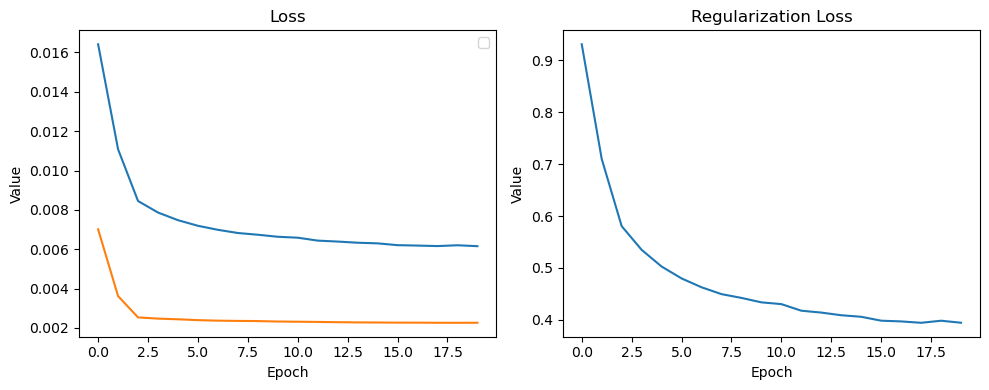

In [265]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(liste_loss)
axs[0].set_title("Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Value")
axs[0].grid(False)

axs[0].plot(liste_loss_sans_regul)
axs[0].set_title("Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Value")
axs[0].grid(False)
axs[0].legend()

axs[1].plot(liste_loss_regul)
axs[1].set_title("Regularization Loss")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Value")
axs[1].grid(False)

plt.tight_layout()
plt.show()


In [124]:
fm_transformer.test(X_test, y_test, X_inlier, 'recons')[0]

(0.6681669269158935, 0.8109365910413031, 0.16261241741436547)

In [123]:
fm_transformer.test(X_test, y_test, X_inlier, 'mahalanobis')[0]

(0.9587765224579774, 0.21058755090168702, 0.77224317780198)

In [71]:
l = []
for i in range(velo_s[:, np.where(y_test != 1)[0], :].shape[1]):
    velo_inlier = velo_s[:, np.where(y_test != 1)[0], :]
    temp = [torch.norm(velo_inlier[j, i , :]).item() for j in range(50)]
    l.append((np.mean(temp), np.std(temp)))

In [72]:
l = np.array(l)
np.mean(l[: , 0]) , np.mean(l[: , 1])

(1.4954653906419986, 0.1146520448494928)

In [73]:
l = []
for i in range(velo_s[:, np.where(y_test == 1)[0], :].shape[1]):
    velo_inlier = velo_s[:, np.where(y_test == 1)[0], :]
    temp = [torch.norm(velo_inlier[j, i , :]).item() for j in range(50)]
    l.append((np.mean(temp), np.std(temp)))

In [74]:
l = np.array(l)
np.mean(l[: , 0]) , np.mean(l[: , 1])

(1.518131601823004, 0.15659538851675708)

In [75]:
z = torch.randn(X_test.shape[0], X_test.shape[1])
x_1 = Tensor(z / z.norm(dim=1, keepdim=True)).to(device)

In [76]:
ll = [torch.norm((x_1 - X_test)[i]).item() for i in range(X_test.shape[0])]

In [77]:
np.mean(ll), np.std(ll)

(1.4139201039103952, 0.025407473079253593)

In [78]:
l = []
for i in range(velo_s[:, :, :].shape[1]):
    temp = [torch.norm(velo_s[j, i , :]).item() for j in range(50)]
    l.append((np.mean(temp), np.std(temp)))

In [79]:
l = np.array(l)

In [80]:
target = 1.4139
k = 5.0 

score = torch.sigmoid(k * torch.abs(Tensor(l[:,0]) - target))

In [81]:
ev.evaluation(y_test, score)

AUC:        0.5116
Avg Precision: 0.1223
FPR@95:     0.9523


(0.511568843574906, 0.9522978475858057, 0.12234431131610507)

In [26]:
y_test

array([0, 1, 0, ..., 0, 0, 0])

In [82]:
sample = 0
# sample = 1
n_steps = 50

for i in range(n_steps -1):
    print(F.cosine_similarity(velo_s[i, sample, :], velo_s[i+1, sample, :], dim=-1).item()) 

0.9968618750572205
0.9974760413169861
0.9979527592658997
0.9983109831809998
0.9985760450363159
0.9987724423408508
0.9989200830459595
0.9990347623825073
0.9991275072097778
0.9992060661315918
0.999275267124176
0.9993380308151245
0.9993956089019775
0.9994480609893799
0.9994955062866211
0.999538004398346
0.9995754361152649
0.9996079802513123
0.9996362328529358
0.9996607303619385
0.9996820688247681
0.9997007250785828
0.9997169971466064
0.999731183052063
0.9997437000274658
0.9997543096542358
0.9997631311416626
0.9997705221176147
0.9997763633728027
0.9997807741165161
0.9997839331626892
0.9997860193252563
0.9997873902320862
0.9997879266738892
0.9997879266738892
0.9997876882553101
0.9997870922088623
0.999786376953125
0.9997854828834534
0.9997845888137817
0.9997838735580444
0.9997832775115967
0.9997829794883728
0.9997830986976624
0.9997835159301758
0.9997844099998474
0.9997857809066772
0.9997876882553101
0.9997901320457458


## ?

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

def sample_mog(n):
    centers = torch.tensor([
        [-2., -2.],
        [-2.,  2.],
        [ 2., -2.],
        [ 2.,  2.]
    ])
    idx = torch.randint(0, len(centers), (n,))
    return centers[idx] + 0.3 * torch.randn(n, 2)

In [53]:
class VelocityNet(nn.Module):
    def __init__(self, dim=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim)
        )

    def forward(self, x, t):
        # x: [B, 2], t: [B]
        t = t.unsqueeze(1)
        return self.net(torch.cat([x, t], dim=1))
    

def rectified_flow_loss(model, x0, x1):
    B = x0.shape[0]
    t = torch.rand(B, device=x0.device)

    xt = (1 - t).unsqueeze(1) * x0 + t.unsqueeze(1) * x1
    v_target = x1 - x0

    v_pred = model(xt, t)
    return ((v_pred - v_target) ** 2).mean()

def flow_matching_loss(model, x0, x1):
    B = x0.shape[0]
    t = torch.rand(B, device=x0.device)

    xt = (1 - t).unsqueeze(1) * x0 + t.unsqueeze(1) * x1
    v_target = x1 - x0   # local mais conditionné par t

    v_pred = model(xt, t)
    return ((v_pred - v_target) ** 2).mean()

@torch.no_grad()
def generate_rectified_targets(model, x0, steps=50):
    B = x0.shape[0]
    x = x0.clone()
    dt = 1.0 / steps

    traj = []
    for i in range(steps):
        t = torch.full((B,), i * dt, device=x.device)
        x = x + model(x, t) * dt
        traj.append(x.clone())

    xT = x
    v_rectified = (xT - x0)  # vitesse constante par trajectoire

    return traj, v_rectified

def rectified_flow_iterative_loss(model, traj, v_rectified):
    losses = []
    steps = len(traj)

    for i, xt in enumerate(traj):
        B = xt.shape[0]
        t = torch.full((B,), i / steps, device=xt.device)
        v_pred = model(xt, t)
        losses.append(((v_pred - v_rectified) ** 2).mean())

    return sum(losses) / len(losses)

In [54]:
device = "cuda" if torch.cuda.is_available() else "cpu"

rf_model = VelocityNet().to(device)
fm_model = VelocityNet().to(device)

rf_opt = optim.Adam(rf_model.parameters(), lr=1e-3)
fm_opt = optim.Adam(fm_model.parameters(), lr=1e-3)


In [55]:
for step in range(3000):
    x0 = torch.randn(512, 2).to(device)
    x1 = sample_mog(512).to(device)

    loss = flow_matching_loss(fm_model, x0, x1)

    fm_opt.zero_grad()
    loss.backward()
    fm_opt.step()


In [56]:
# Pré-entrainement RF
for step in range(2000):
    x0 = torch.randn(512, 2).to(device)
    x1 = sample_mog(512).to(device)

    loss = rectified_flow_loss(rf_model, x0, x1)

    if step % (2000 // 5) == 0:
        print(f"loss = {loss.item():.4f}")

    rf_opt.zero_grad()
    loss.backward()
    rf_opt.step()


loss = 4.9535
loss = 2.7081
loss = 2.5659
loss = 2.7028
loss = 2.7384


In [57]:
# Rectification itérative
for iteration in range(2):
    x0 = torch.randn(512, 2).to(device)

    traj, v_rectified = generate_rectified_targets(rf_model, x0)
    loss = rectified_flow_iterative_loss(rf_model, traj, v_rectified)

    rf_opt.zero_grad()
    loss.backward()
    rf_opt.step()

    print(f"Rectification iteration {iteration}, loss = {loss.item():.4f}")


Rectification iteration 0, loss = 0.9657
Rectification iteration 1, loss = 0.9445


In [58]:
@torch.no_grad()
def sample(model, n=2000, steps=100):
    x = torch.randn(n, 2).to(device)
    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full((n,), i * dt, device=device)
        x = x + model(x, t) * dt

    return x.cpu()

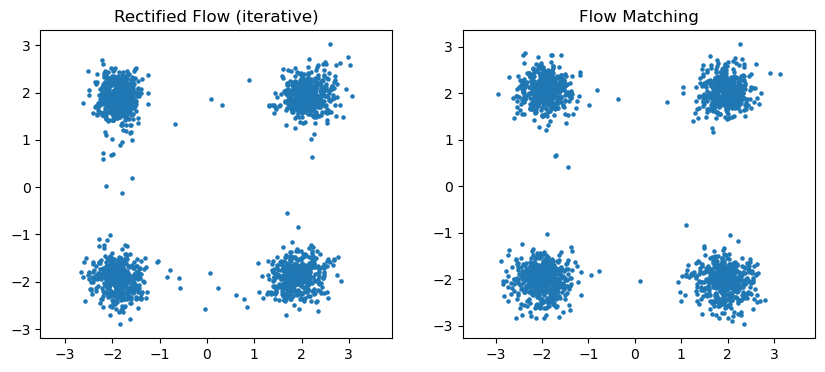

In [59]:
rf_samples = sample(rf_model)
fm_samples = sample(fm_model)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(rf_samples[:, 0], rf_samples[:, 1], s=5)
plt.title("Rectified Flow (iterative)")
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.scatter(fm_samples[:, 0], fm_samples[:, 1], s=5)
plt.title("Flow Matching")
plt.axis("equal")

plt.show()

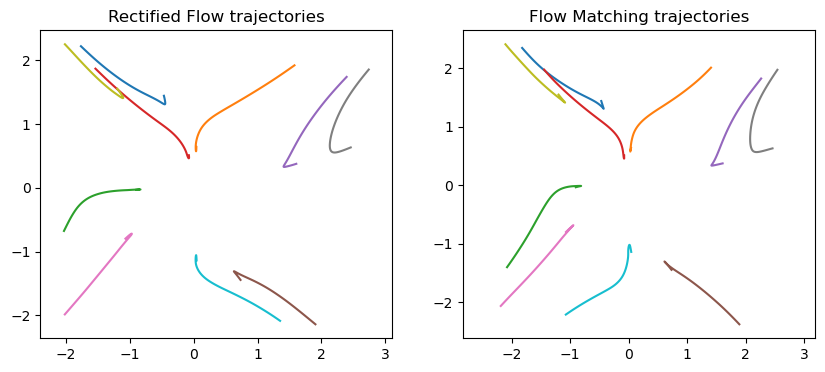

In [60]:
@torch.no_grad()
def generate_trajectories(model, x0, steps=100):
    """
    x0: [B, 2]
    return: traj [steps+1, B, 2]
    """
    B = x0.shape[0]
    x = x0.clone()
    dt = 1.0 / steps

    traj = [x.clone()]

    for i in range(steps):
        t = torch.full((B,), i * dt, device=x.device)
        v = model(x, t)
        x = x + v * dt
        traj.append(x.clone())

    return torch.stack(traj)
def plot_trajectory_comparison(rf_model, fm_model, n=10, steps=100):
    device = next(rf_model.parameters()).device
    x0 = torch.randn(n, 2).to(device)

    rf_traj = generate_trajectories(rf_model, x0, steps).cpu()
    fm_traj = generate_trajectories(fm_model, x0, steps).cpu()

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    for i in range(n):
        plt.plot(rf_traj[:, i, 0], rf_traj[:, i, 1])
    plt.title("Rectified Flow trajectories")
    plt.axis("equal")

    plt.subplot(1, 2, 2)
    for i in range(n):
        plt.plot(fm_traj[:, i, 0], fm_traj[:, i, 1])
    plt.title("Flow Matching trajectories")
    plt.axis("equal")

    plt.show()


plot_trajectory_comparison(rf_model, fm_model)


In [45]:
def compute_velocity(traj):
    """
    traj: [T, B, 2]
    return: velocities [T-1, B, 2]
    """
    return traj[1:] - traj[:-1]

def compute_curvature(vel, eps=1e-8):
    """
    vel: [T-1, B, 2]
    return: curvature [T-2, B]
    """
    v1 = vel[:-1]
    v2 = vel[1:]

    dot = (v1 * v2).sum(dim=-1)
    n1 = torch.norm(v1, dim=-1)
    n2 = torch.norm(v2, dim=-1)

    cos = dot / (n1 * n2 + eps)
    return 1 - cos

def velocity_norm_variation(vel):
    """
    vel: [T-1, B, 2]
    return: std over time [B]
    """
    norms = torch.norm(vel, dim=-1)
    return norms.std(dim=0)


In [46]:
def compare_geometry(rf_model, fm_model, n=512, steps=100):
    x0 = torch.randn(n, 2).to(next(rf_model.parameters()).device)

    rf_traj = generate_trajectories(rf_model, x0, steps)
    fm_traj = generate_trajectories(fm_model, x0, steps)

    rf_vel = compute_velocity(rf_traj)
    fm_vel = compute_velocity(fm_traj)

    rf_curv = compute_curvature(rf_vel).mean().item()
    fm_curv = compute_curvature(fm_vel).mean().item()

    rf_var = velocity_norm_variation(rf_vel).mean().item()
    fm_var = velocity_norm_variation(fm_vel).mean().item()

    print("=== Geometry comparison ===")
    print(f"Mean curvature  | RF : {rf_curv:.4f} | FM : {fm_curv:.4f}")
    print(f"Velocity std    | RF : {rf_var:.4f} | FM : {fm_var:.4f}")


In [47]:
compare_geometry(rf_model, fm_model)

=== Geometry comparison ===
Mean curvature  | RF : 0.0047 | FM : 0.0082
Velocity std    | RF : 0.0054 | FM : 0.0107


In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = VelocityNet().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)

for step in range(5000):
    x0 = torch.randn(512, 2).to(device)
    x1 = sample_mog(512).to(device)

    loss = rectified_flow_loss(model, x0, x1)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 500 == 0:
        print(f"step {step}, loss = {loss.item():.4f}")


step 0, loss = 4.8743
step 500, loss = 2.8474
step 1000, loss = 2.3083
step 1500, loss = 2.7385
step 2000, loss = 2.5259
step 2500, loss = 2.4350
step 3000, loss = 2.3801
step 3500, loss = 2.4819
step 4000, loss = 2.4111
step 4500, loss = 2.5321


In [13]:
@torch.no_grad()
def sample_rectified_flow(model, n=2000, steps=100):
    x = torch.randn(n, 2).to(device)
    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full((n,), i * dt, device=device)
        v = model(x, t)
        x = x + v * dt

    return x.cpu()

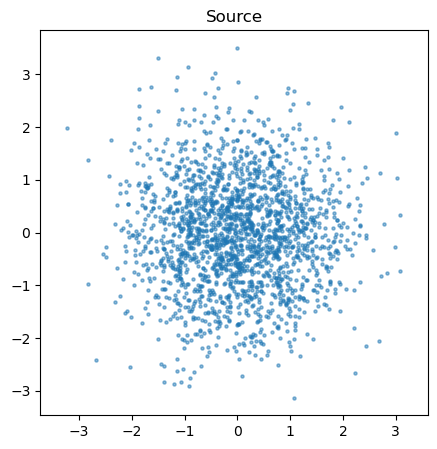

In [17]:
x = torch.randn(2000, 2)
plt.figure(figsize=(5, 5))
plt.scatter(x[:, 0], x[:, 1], s=5, alpha=0.5)
plt.title("Source")
plt.axis("equal")
plt.show()

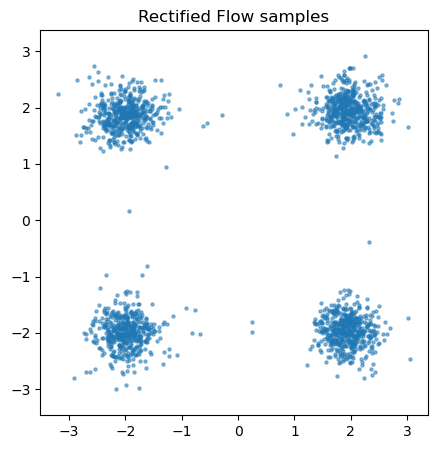

In [14]:
samples = sample_rectified_flow(model)

plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.5)
plt.title("Rectified Flow samples")
plt.axis("equal")
plt.show()


In [18]:
@torch.no_grad()
def plot_trajectories(model, n=15, steps=100):
    x = torch.randn(n, 2).to(device)
    traj = [x.cpu()]

    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((n,), i * dt, device=device)
        x = x + model(x, t) * dt
        traj.append(x.cpu())

    traj = torch.stack(traj)

    for i in range(n):
        plt.plot(traj[:, i, 0], traj[:, i, 1])

    plt.title("Rectified Flow trajectories")
    plt.axis("equal")
    plt.show()


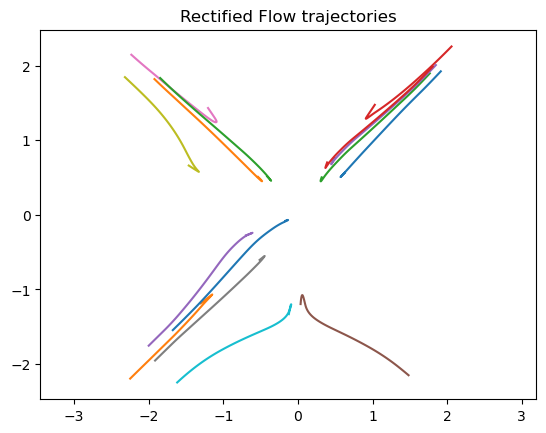

In [ ]:
plot_trajectories(model)

## Ablation

In [6]:
from Modelisation.FlowMatching.flow_matching_transformers import *

inlier_topics = ['World', 'Sports', 'Business', 'Sci-Tech']
liste_gaussian = []
for inlier_topic in inlier_topics:
    print(inlier_topic)
    # inlier_topic = 'computer'
    dataset_name = 'agnews'
    type_tac = 'ruff'
    anomaly_rate = 0.1
    save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
    data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
    X_inlier = Tensor(data_train['sbert_embeddings']).to(device)
    temp_gaussian = []
    for n_run in range(1, 11):

        #######################################################

        data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
        X_test =  Tensor(data_test['sbert_embeddings']).to(device)
        y_test = np.array(data_test['anomaly_class'])

        config = {
                    'latent_dim': 768,
                    'hidden_dim': 64,
                    'depth': 2,
                    'n_heads': 2,
                    'lr': 1e-3,
                    'weight_decay': 1e-5,
                    'epochs': 20,
                    'warmup_epochs': 5,
                    'grad_clip': 1.0,
                    'flow_type': 'linear',  
                    'sigma': 0.1, 
                    'batch_size' : 128,
                    'lambda_reg_angle': None,
                    'target' : 'gaussian',
                    'source' : X_inlier.to(device)
                    # 'source' : X_inlier + torch.randn_like(X_inlier).to(device)
                    # 'source' : torch.concatenate([X_inlier, X_anom_for_train]).to(device)   
        }

        model = FlowDiT(
            latent_dim=config['latent_dim'],
            hidden_dim=config['hidden_dim'],
            depth=config['depth'],
            n_heads=config['n_heads']
        ).to(device)

        fm_transformer = FlowMatchingTransformers(model, config['source'], config['target'], config, noise_is_target=True, rectified=None)
        liste_loss, liste_loss_regul = fm_transformer.train(X_inlier, False)

        scores, velo_s = fm_transformer.test(X_test, y_test, X_inlier, 'mahalanobis')
        velo_s = torch.stack(velo_s)
        temp_gaussian.append(scores)

    liste_gaussian.append(temp_gaussian)


World
Sports
Business
Sci-Tech


In [154]:
liste_aller = np.array(liste_aller)
liste_retour = np.array(liste_retour)

print(liste_aller.mean(axis=(0,1)) - liste_retour.mean(axis=(0,1)))
print(liste_aller.std(axis=(0,1)) - liste_retour.std(axis=(0,1)))

[-0.00015743  0.00377193  0.00015404]
[0.00027351 0.00458322 0.00043477]


In [155]:
from scipy.stats import mannwhitneyu

liste_aller = np.array(liste_aller)
liste_retour = np.array(liste_retour)

liste_aller_flat = liste_aller.reshape(-1, 3)
liste_retour_flat = liste_retour.reshape(-1, 3)

metric_names = ['AUC', 'FPR95', 'AP']

for i in range(3):
    stat, p = mannwhitneyu(liste_aller_flat[:, i], liste_retour_flat[:, i])
    print(f"{metric_names[i]} p-value:", p)


AUC p-value: 0.9654613787091454
FPR95 p-value: 0.9271557139425899
AP p-value: 0.9654613787091454


In [7]:
liste_gaussian = np.array(liste_gaussian)
liste_gaussian[:].mean(axis=0).mean(axis=0)

array([0.93781987, 0.27140351, 0.70268046])

## EBMs

In [285]:
# np.random.seed(42)
# n_samples = 500

# theta = np.random.uniform(0, 2*np.pi, n_samples)
# r = np.random.normal(loc=2.0, scale=0.3, size=n_samples)
# x = r * np.cos(theta)
# y = r * np.sin(theta)
# data = np.stack([x, y], axis=1)
# data = torch.tensor(data, dtype=torch.float32)

# anomalies = torch.tensor([[4,4],[5,0],[-4,-3], [2,2.2], [-2,-2]], dtype=torch.float32)

# plt.scatter(data[:,0], data[:,1], label="Normal", alpha=0.6)
# plt.scatter(anomalies[:,0], anomalies[:,1], label="Anomaly", color='r', s=100)
# plt.legend()
# plt.title("Dataset Jouet")
# plt.show()

# xx, yy = np.meshgrid(np.linspace(-6,6,100), np.linspace(-6,6,100))
# grid = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1), dtype=torch.float32)
# with torch.no_grad():
#     energies = model(grid).numpy()
# energies = energies.reshape(xx.shape)

# plt.contourf(xx, yy, energies, levels=50, cmap='viridis')
# plt.colorbar(label="Energy V(x)")
# plt.scatter(data[:,0], data[:,1], label="Normal", alpha=0.6, color='white')
# plt.scatter(anomalies[:,0], anomalies[:,1], label="Anomaly", color='red', s=100)
# plt.legend()
# plt.title("Champ d'énergie appris par EBM")
# plt.show()

In [271]:
class EBM(nn.Module):
    def __init__(self, input_dim=2, dim_hid=64):
        super().__init__()
        self.dim_hid = dim_hid
        self.input_dim = input_dim
        self.net = nn.Sequential(
            nn.Linear(self.input_dim, self.dim_hid),
            nn.ReLU(),
            nn.Linear(self.dim_hid, self.dim_hid),
            nn.ReLU(),
            nn.Linear(self.dim_hid, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = EBM(X_inlier.shape[1], 64).to(device)

lr = 1e-3
batch_size = 64
epochs = 10
K = 20            # Langevin steps
eta = 1e-2        # step size Langevin
eps = 0.05        # bruit Langevin
optimizer = optim.Adam(model.parameters(), lr=lr)

def langevin_samples(x_init, model, K=20, eta=0.1, eps=0.01):
    x = x_init.clone().detach()
    x.requires_grad_(True)
    for _ in range(K):
        energy = model(x)
        grad = torch.autograd.grad(energy.sum(), x)[0]
        x.data -= eta * grad + torch.randn_like(x) * np.sqrt(2*eta*eps)
    return x.detach()

Epoch 0: CD loss = -1.3617


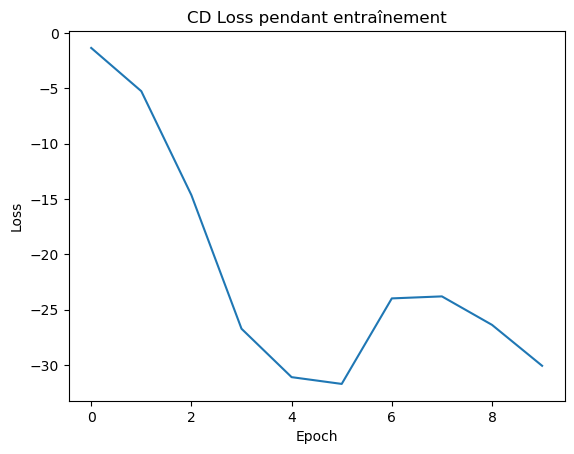

In [272]:
# data_loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

loss_history = []
for epoch in range(epochs):
    for x_batch, in X_inlier_dl:
        noise = torch.randn_like(x_batch)
        x_neg_init = torch.cat([x_batch, noise], dim=0)
        x_neg = langevin_samples(x_neg_init, model, K=K, eta=eta, eps=eps)

        energy_pos = model(x_batch)
        energy_neg = model(x_neg)
        loss = (energy_pos.mean() - energy_neg.mean())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    loss_history.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: CD loss = {loss.item():.4f}")

plt.plot(loss_history)
plt.title("CD Loss pendant entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [273]:
ev.evaluation(y_test, model(X_test).cpu().detach().numpy())

AUC:        0.9123
Avg Precision: 0.6983
FPR@95:     0.4159


(0.9122684547319433, 0.41593949970913324, 0.6983106576577038)

In [4]:
import datasets
from datasets import concatenate_datasets
import os

nu = 0.1
path = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/ds_train_{inlier_topic}_anomaly_{int(nu*100)}.pt")
data_train_anomaly = datasets.load_from_disk(path)
X_anom_for_train = Tensor(data_train_anomaly['sbert_embeddings']).to(device) 

In [34]:
nb_random_samples = 1000

config = {
        'latent_dim': 768,
        'hidden_dim': 64,
        'depth': 2,
        'n_heads': 2,
        'lr': 1e-3,
        'weight_decay': 1e-5,
        'epochs': 500,
        'warmup_epochs': 50,
        'grad_clip': 1.0,
        'flow_type': 'linear',  
        'sigma': 0.1, 
        'batch_size' : 64,
        'lambda_reg_angle': None,
        'lambda_reg_kl': None,
        'coef_var': 1,
        'target' : 'gaussian-neigh',
        'source' : X_inlier.to(device)
        # 'source' : torch.concatenate((X_inlier.to(device), 0.2*torch.zeros(nb_random_samples, X_inlier.shape[1]).to(device) + (0.008 ** 0.5) * torch.randn((nb_random_samples, 768)).to(device)))
        # 'source' : torch.concatenate((X_inlier.to(device), X_inlier.to(device)))
        # 'source' : torch.concatenate((X_inlier.to(device), torch.randn(100, X_inlier.shape[1]).to(device)))
        # 'source' : X_inlier + torch.randn_like(X_inlier).to(device)
        # 'source' : torch.concatenate([X_inlier, X_anom_for_train]).to(device)   
}
noise_is_target = True
naming_dis = {
    'target' : config['target'] if noise_is_target else 'SBert', 
    'source' : config['source'] if not noise_is_target else 'SBert'
}

y_train = np.concatenate([np.zeros(X_inlier.shape[0]), np.ones(X_anom_for_train.shape[0])])
# y_train = np.concatenate([np.zeros(X_inlier.shape[0]), np.ones(nb_random_samples)])

# flowmodel = FlowDiT(
#                 latent_dim=config['latent_dim'],
#                 hidden_dim=config['hidden_dim'],
#                 depth=config['depth'],
#                 n_heads=config['n_heads']
#         ).to(device)

# fm_transformer = FlowMatchingTransformers(flowmodel, config['source'], config['target'], config, noise_is_target=noise_is_target, rectified=None)
# liste_loss, liste_loss_regul = fm_transformer.train(X_inlier, True)

In [35]:
for _ in range(1):

    flowmodel = FlowDiT(
                latent_dim=config['latent_dim'],
                hidden_dim=config['hidden_dim'],
                depth=config['depth'],
                n_heads=config['n_heads']
        ).to(device)

    fm_transformer = FlowMatchingTransformers(flowmodel, config['source'], config['target'], config, noise_is_target=noise_is_target, rectified=None)
    liste_loss, liste_loss_regul = fm_transformer.train(True)

    scores = fm_transformer.test(X_test, y_test, X_inlier, 'norm-centroid')


Epoch 1/500
Train Loss: 0.0079, LR: 0.000020

Epoch 167/500
Train Loss: 0.0018, LR: 0.000845

Epoch 333/500
Train Loss: 0.0018, LR: 0.000306

Epoch 499/500
Train Loss: 0.0018, LR: 0.000000


In [36]:
scores = fm_transformer.test(X_test, y_test, X_inlier, 'norm-centroid')
print(scores)

(0.9373993447842992, 0.30424665503199533, 0.7874823939684826)


In [37]:
n_steps = 8
x_intermer_test_noise = fm_transformer.forward_flow(X_test,'midpoint',n_steps)
x_intermer_inlier_noise = fm_transformer.forward_flow(X_inlier,'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate((X_inlier.to(device), torch.randn(100, X_inlier.shape[1]).to(device))),'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate((X_inlier.to(device), 0.2*torch.zeros(nb_random_samples, X_inlier.shape[1]).to(device) + (0.008 ** 0.5) * torch.randn((nb_random_samples, 768)).to(device))),'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate((X_inlier.to(device), X_inlier.to(device) )),'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate([X_inlier, X_anom_for_train]).to(device),'midpoint',n_steps)

metrics_history_maha = []
metrics_history_norm = []
metrics_history_norm_train = []

for num_repre_space in range(n_steps):

    ############## MANALANOBIS ####################

    x_1_inliers = x_intermer_inlier_noise[num_repre_space].cpu().numpy()

    mean_inlier = np.mean(x_1_inliers, axis=0)
    cov_inlier = np.cov(x_1_inliers.T)
    cov_inlier += 1e-6 * np.eye(cov_inlier.shape[0])

    diff = x_intermer_test_noise[num_repre_space].cpu().numpy() - mean_inlier
    inv_cov = np.linalg.inv(cov_inlier)

    scores = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))
    metrics_history_maha.append(ev.evaluation(y_test, scores, verbose=False))


    ################### NORM ########################

    # scores = np.sum(x_intermer_test_noise[num_repre_space].cpu().numpy() ** 2, axis=1)
    scores = np.sum((x_intermer_test_noise[num_repre_space].cpu().numpy() - fm_transformer.centroid.repeat(x_intermer_test_noise[num_repre_space].cpu().numpy().shape[0],1).cpu().numpy()) ** 2, axis=1)
    metrics_history_norm.append(ev.evaluation(y_test, scores, verbose=False))

    # # # ss = np.sum(x_intermer_inlier_noise[num_repre_space].cpu().numpy() ** 2, axis=1)
    # ss = np.sum((x_intermer_inlier_noise[num_repre_space].cpu().numpy() - fm_transformer.centroid.repeat(x_intermer_inlier_noise[num_repre_space].cpu().numpy().shape[0],1).cpu().numpy()) ** 2, axis=1)
    # metrics_history_norm_train.append(ev.evaluation(y_train, ss, verbose=False))

metrics_history_maha = np.array(metrics_history_maha)
metrics_history_norm = np.array(metrics_history_norm)
metrics_history_norm_train = np.array(metrics_history_norm_train)

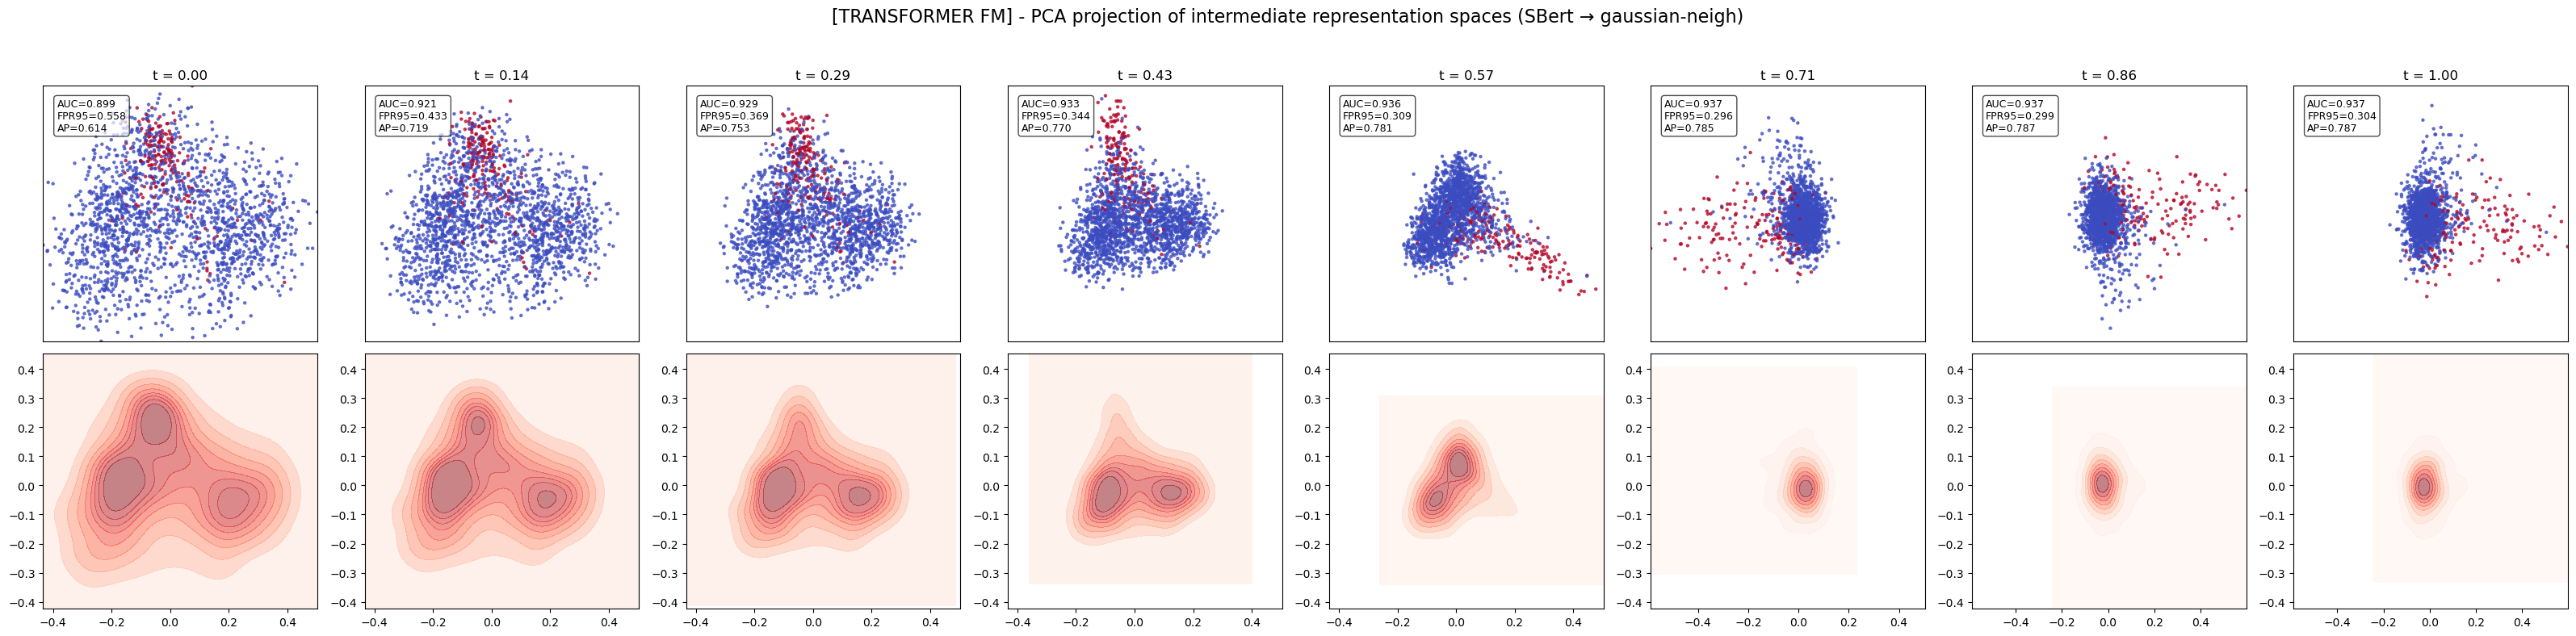

In [38]:
X_np = x_intermer_test_noise.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    X_2d_list = []
    for i in range(n_steps):
        if "t-SNE" in algos:
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])
        X_2d_list.append(X_2d)

        all_X = np.concatenate(X_2d_list, axis=0)
        x_min, x_max = all_X[:, 0].min(), all_X[:, 0].max()
        y_min, y_max = all_X[:, 1].min(), all_X[:, 1].max()

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            c=y_test,
            cmap="coolwarm",
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])
        ax_scatter.set_xlim(x_min, x_max)
        ax_scatter.set_ylim(y_min, y_max)

        ax_scatter.text(
            0.05, 0.95,
            f"AUC={metrics_history_norm[i][0]:.3f}\n"
            f"FPR95={metrics_history_norm[i][1]:.3f}\n"
            f"AP={metrics_history_norm[i][2]:.3f}",
            transform=ax_scatter.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        )
        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(x_min, x_max)
        ax_kde.set_ylim(y_min, y_max)

    fig.suptitle(
        f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

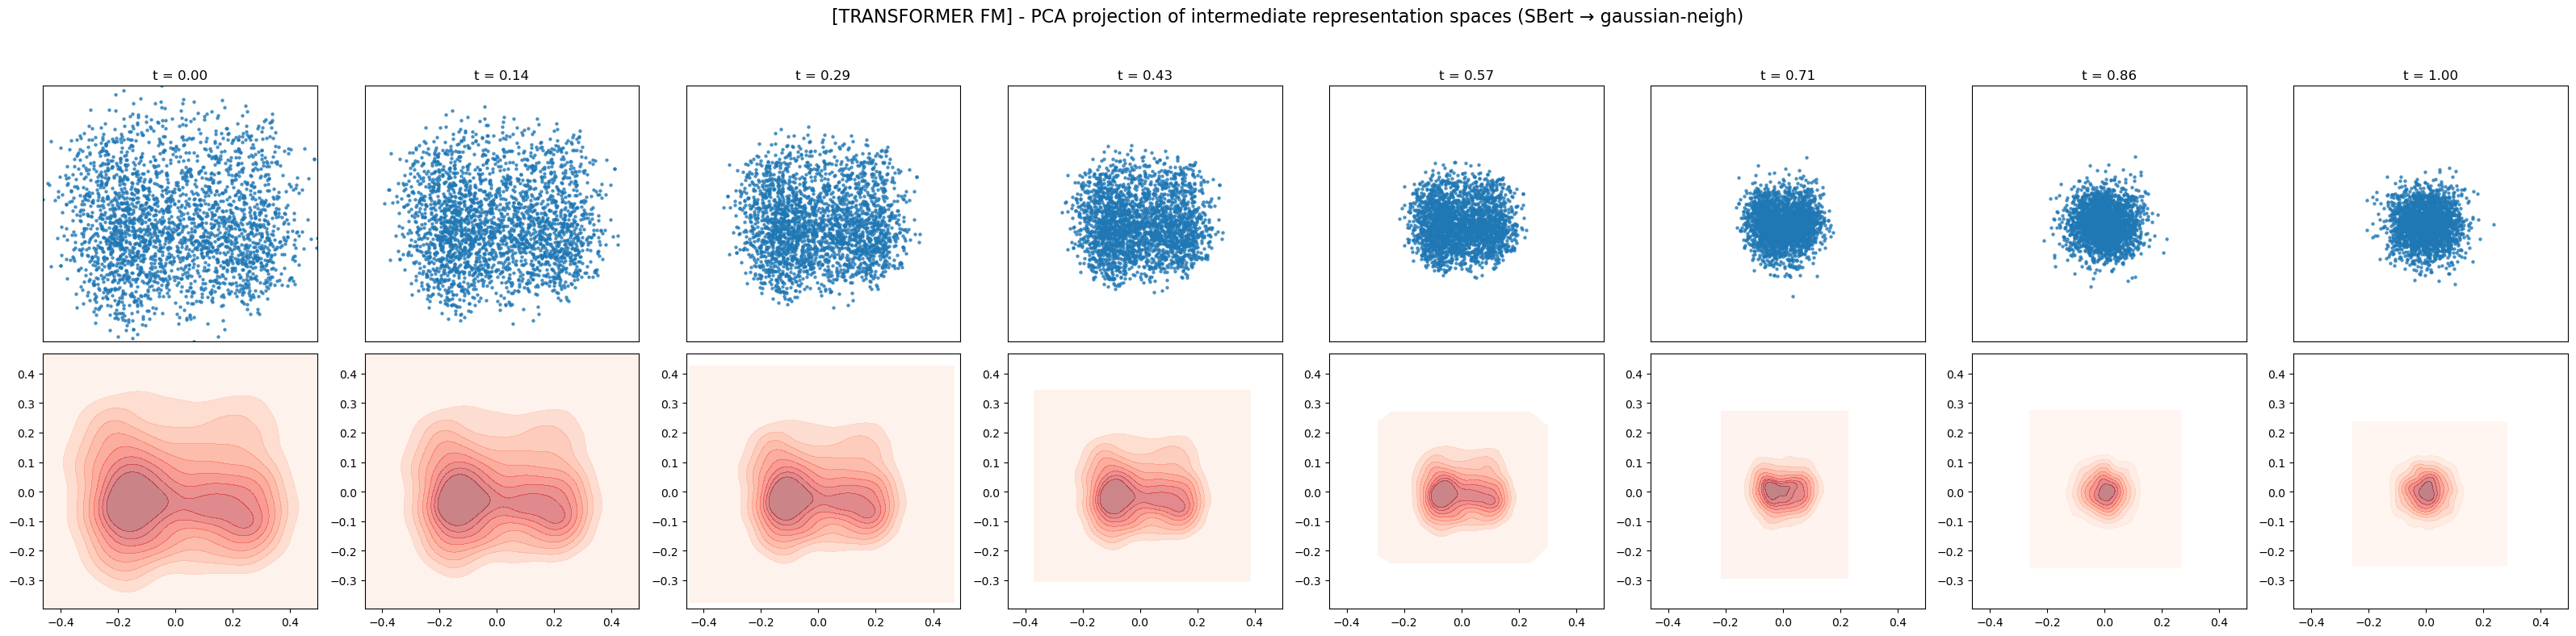

In [39]:
X_np = x_intermer_inlier_noise.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    X_2d_list = []
    for i in range(n_steps):
        if "t-SNE" in algos:
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])
        X_2d_list.append(X_2d)

        all_X = np.concatenate(X_2d_list, axis=0)
        x_min, x_max = all_X[:, 0].min(), all_X[:, 0].max()
        y_min, y_max = all_X[:, 1].min(), all_X[:, 1].max()

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            # c=y_train,
            # cmap="bwr",
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])
        ax_scatter.set_xlim(x_min, x_max)
        ax_scatter.set_ylim(y_min, y_max)

        # ax_scatter.text(
        #     0.05, 0.95,
        #     f"AUC={metrics_history_norm_train[i][0]:.3f}\n"
        #     f"FPR95={metrics_history_norm_train[i][1]:.3f}\n"
        #     f"AP={metrics_history_norm_train[i][2]:.3f}",
        #     transform=ax_scatter.transAxes,
        #     fontsize=9,
        #     verticalalignment='top',
        #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        # )
        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(x_min, x_max)
        ax_kde.set_ylim(y_min, y_max)

    fig.suptitle(
        f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [50]:
def gaussian_membership_batch(X, mu, sigma, alpha=0.95):
    dim = mu.shape[0]
    
    chi2_threshold = chi2.ppf(alpha, df=dim)
    R = np.sqrt(chi2_threshold) * sigma
    
    distances = np.linalg.norm(X - mu, axis=1)
    
    # True = inside Gaussian
    return distances <= R

In [57]:
x = x_intermer_test_noise[-1].cpu().numpy()
l = gaussian_membership_batch(x, x.mean(axis=0), x.var(axis=0).mean(), alpha=0.95)

In [58]:
np.unique(l, return_counts=True)

(array([False]), array([1909]))

In [ ]:
from scipy.stats import chi2

def belongs_to_gaussian_isotropic(x, mu, sigma, alpha=0.95):
    """
    x : shape (768,) or (n,768)
    mu : shape (768,)
    sigma : scalar (std)
    alpha : confidence level
    """
    x = np.atleast_2d(x)
    d = mu.shape[0]
    
    diff = x - mu
    maha_sq = np.sum(diff**2, axis=1) / (sigma**2)
    
    threshold = chi2.ppf(alpha, df=d)
    
    return maha_sq <= threshold

(array([False]), array([1909]))

In [82]:
def collect_temporal_metrics(model, x, time_steps):
    norms = []
    dvdt_vals = []

    for t in time_steps:
        t_batch = torch.ones(x.size(0), 1, device=x.device) * t
        t_batch.requires_grad_(True)

        v = model(x, t_batch)

        norm_v = v.norm(dim=1)
        norms.append(norm_v.detach())

        dvdt = torch.autograd.grad(
            norm_v.sum(),
            t_batch,
            retain_graph=True
        )[0]

        dvdt_vals.append(dvdt.detach())

    norms = torch.stack(norms, dim=1)
    dvdt_vals = torch.stack(dvdt_vals, dim=1)

    return norms, dvdt_vals

In [83]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
norms_inlier, dvdt_vals = collect_temporal_metrics(fm_transformer.model, X_inlier, time_steps)
norms_test, dvdt_vals = collect_temporal_metrics(fm_transformer.model, X_test, time_steps)

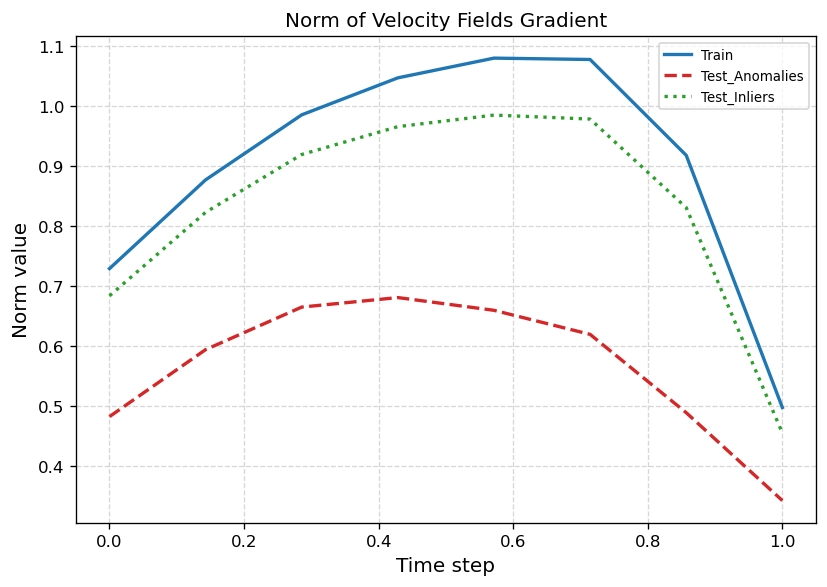

In [84]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
plt.figure(figsize=(7, 5), dpi=120)

plt.plot(time_steps, torch.mean(norms_inlier, dim=0).cpu().numpy(), label='Train', color='tab:blue', linewidth=2)
plt.plot(time_steps, torch.mean(norms_test[y_test == 1], dim=0).cpu().numpy(), label='Test_Anomalies', color='tab:red', linewidth=2, linestyle='--')
plt.plot(time_steps, torch.mean(norms_test[y_test == 0], dim=0).cpu().numpy(), label='Test_Inliers', color='tab:green', linewidth=2, linestyle=':')

plt.xlabel('Time step', fontsize=12)
plt.ylabel('Norm value', fontsize=12)
plt.title('Norm of Velocity Fields Gradient', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [66]:
plt.imshow(norms_test[y_test==1].cpu(), aspect='auto')
# plt.imshow(norms_inlier.cpu(), aspect='auto')
plt.colorbar()
plt.title("Velocity norm per sample over time")
plt.show()

IndexError: The shape of the mask [1909] at index 0 does not match the shape of the indexed tensor [15] at index 0

In [85]:
def grad_norm(model, x, t):
    x = x.requires_grad_(True)
    v = model(x, t)

    grad = torch.autograd.grad(
        v.norm(),
        x,
        retain_graph=False,
        create_graph=False
    )[0]

    return grad.norm(dim=1)

In [86]:
dt = 1.0 / n_steps
l_norm_train = []

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(X_inlier.shape[0])
    l_norm_train.append(torch.mean(grad_norm(fm_transformer.model, X_inlier, t)).item())

l_norm_anom = []
l_norm_inlier = []

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(X_test[y_test==1].shape[0])
    l_norm_anom.append(torch.mean(grad_norm(fm_transformer.model, X_test[y_test==1], t)).item())

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(X_test[y_test==0].shape[0])
    l_norm_inlier.append(torch.mean(grad_norm(fm_transformer.model, X_test[y_test==0], t)).item())

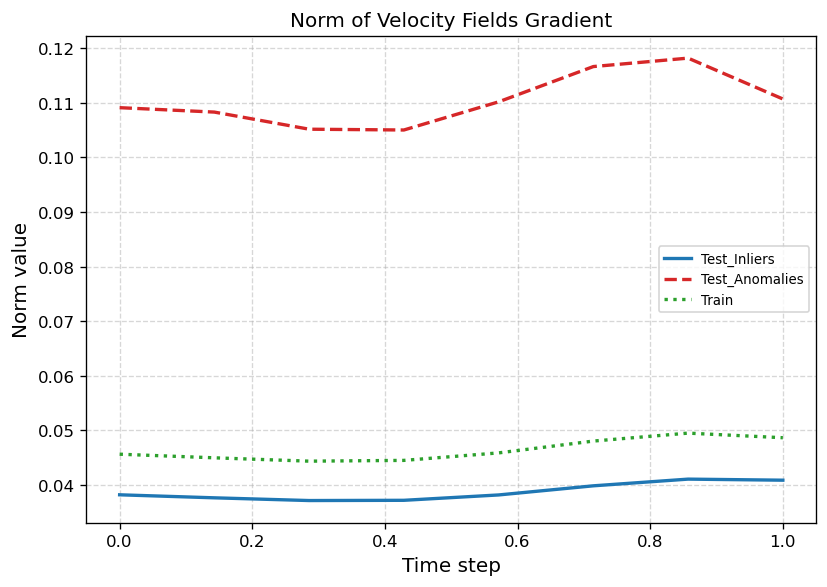

In [87]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
plt.figure(figsize=(7, 5), dpi=120)

plt.plot(time_steps, l_norm_train, label='Test_Inliers', color='tab:blue', linewidth=2)
plt.plot(time_steps, l_norm_anom, label='Test_Anomalies', color='tab:red', linewidth=2, linestyle='--')
plt.plot(time_steps, l_norm_inlier, label='Train', color='tab:green', linewidth=2, linestyle=':')

plt.xlabel('Time step', fontsize=12)
plt.ylabel('Norm value', fontsize=12)
plt.title('Norm of Velocity Fields Gradient', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
x0 = X_test
x_t = x0.clone().to(device)
x_traj_test = [x_t.clone()]
v_fields_test = []

dt = 1.0 / n_steps

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(x_t.shape[0])
    v_t = fm_transformer.model(x_t, t)
    v_fields_test.append(v_t.clone())
    x_t = x_t + dt * v_t
    x_traj_test.append(x_t.clone())

v_fields_test = torch.stack(v_fields_test)
x_traj_test = torch.stack(x_traj_test)

In [10]:
indices_inlier = np.where(y_test == 0)[0]
indices_anomaly = np.where(y_test == 1)[0]

norm_inlier = []
norm_anomaly = []

for t_ in range(n_steps):
    test_velocities_inlier_norm = torch.norm(v_fields_test[t_, indices_inlier], dim=1)
    test_velocities_anomaly_norm = torch.norm(v_fields_test[t_, indices_anomaly], dim=1)

    norm_inlier.append(torch.mean(test_velocities_inlier_norm).item())
    norm_anomaly.append(torch.mean(test_velocities_anomaly_norm).item())

norm_inlier = np.array(norm_inlier)
norm_anomaly = np.array(norm_anomaly)

In [11]:
# x0 = torch.concatenate((X_inlier.to(device), 0.2*torch.zeros(nb_random_samples, X_inlier.shape[1]).to(device) + (0.008 ** 0.5) * torch.randn((nb_random_samples, 768)).to(device)))
x0 = X_inlier.to(device)
x_t = x0.clone().to(device)
x_traj_train = [x_t.clone()]
v_fields_train = []

dt = 1.0 / n_steps

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(x_t.shape[0])
    v_t = fm_transformer.model(x_t, t)
    v_fields_train.append(v_t.clone())
    x_t = x_t + dt * v_t
    x_traj_train.append(x_t.clone())

v_fields_train = torch.stack(v_fields_train)
x_traj_train = torch.stack(x_traj_train)

In [12]:
norm_train = []
for t_ in range(n_steps):
    train_velocities_norm = torch.norm(v_fields_train[t_, :], dim=1)
    norm_train.append(torch.mean(train_velocities_norm).item())

norm_train = np.array(norm_train)

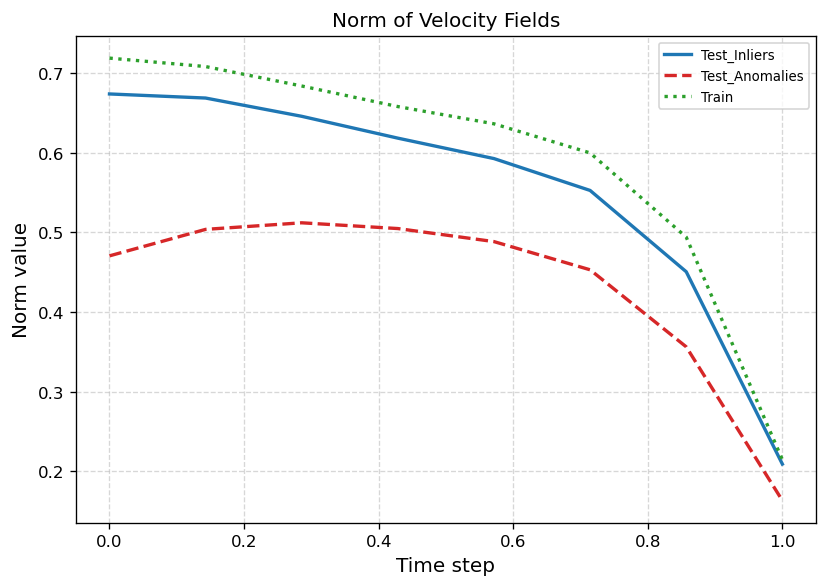

In [13]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
plt.figure(figsize=(7, 5), dpi=120)

plt.plot(time_steps, norm_inlier, label='Test_Inliers', color='tab:blue', linewidth=2)
plt.plot(time_steps, norm_anomaly, label='Test_Anomalies', color='tab:red', linewidth=2, linestyle='--')
plt.plot(time_steps, norm_train, label='Train', color='tab:green', linewidth=2, linestyle=':')

plt.xlabel('Time step', fontsize=12)
plt.ylabel('Norm value', fontsize=12)
plt.title('Norm of Velocity Fields', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
torch.mean(torch.norm((fm_transformer.sample(X_test, 'gaussian-neigh') - X_test), dim=1))

tensor(1.3136, device='cuda:0')

In [18]:
torch.mean(torch.norm((fm_transformer.sample(X_inlier, 'gaussian-neigh') - X_inlier), dim=1))

tensor(1.3053, device='cuda:0')

In [29]:
torch.mean(v_fields_test[:, y_test==0, :], dim=1).shape

torch.Size([8, 768])

In [30]:
torch.mean(v_fields_test[:, y_test==1, :], dim=1).shape

torch.Size([8, 768])

In [37]:
v_in = torch.mean(v_fields_test[:, y_test==0, :], dim=1)   
diff = torch.abs(v_in)  
importance_in = torch.mean(diff, dim=0)  

v_out = torch.mean(v_fields_test[:, y_test==1, :], dim=1)
diff = torch.abs(v_out)  
importance_out = torch.mean(diff, dim=0)  

top3_values, top3_indices = torch.topk(importance_in, k=3)
print("INLIER")
print("Top 3 dimensions :", top3_indices)
print("Importance scores :", top3_values)
print()
top3_values, top3_indices = torch.topk(importance_out, k=3)
print("ANOMALIES ")
print("Top 3 dimensions :", top3_indices)
print("Importance scores :", top3_values)

INLIER
Top 3 dimensions : tensor([611,  21, 267], device='cuda:0')
Importance scores : tensor([0.0046, 0.0037, 0.0037], device='cuda:0', grad_fn=<TopkBackward0>)

ANOMALIES 
Top 3 dimensions : tensor([ 97, 689, 365], device='cuda:0')
Importance scores : tensor([0.0300, 0.0258, 0.0238], device='cuda:0', grad_fn=<TopkBackward0>)


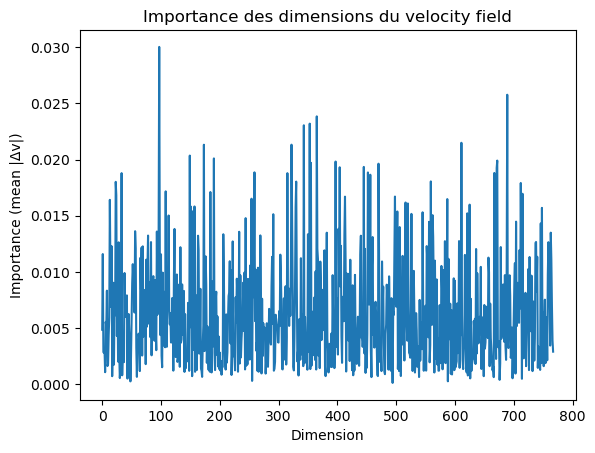

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(importance_out.cpu().detach().numpy())
plt.xlabel("Dimension")
plt.ylabel("Importance (mean |Δv|)")
plt.title("Importance des dimensions du velocity field")
plt.show()

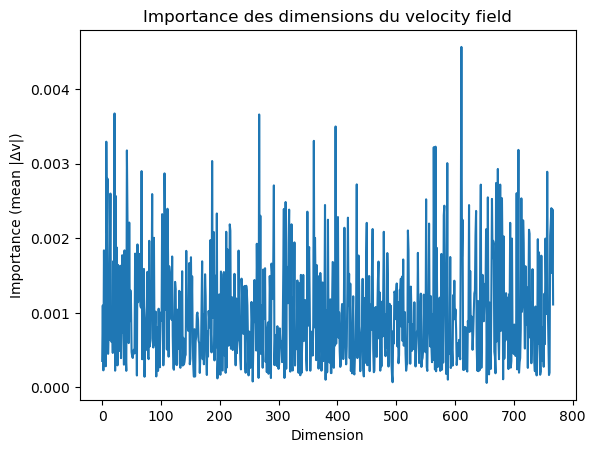

In [39]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(importance_in.cpu().detach().numpy())
plt.xlabel("Dimension")
plt.ylabel("Importance (mean |Δv|)")
plt.title("Importance des dimensions du velocity field")
plt.show()

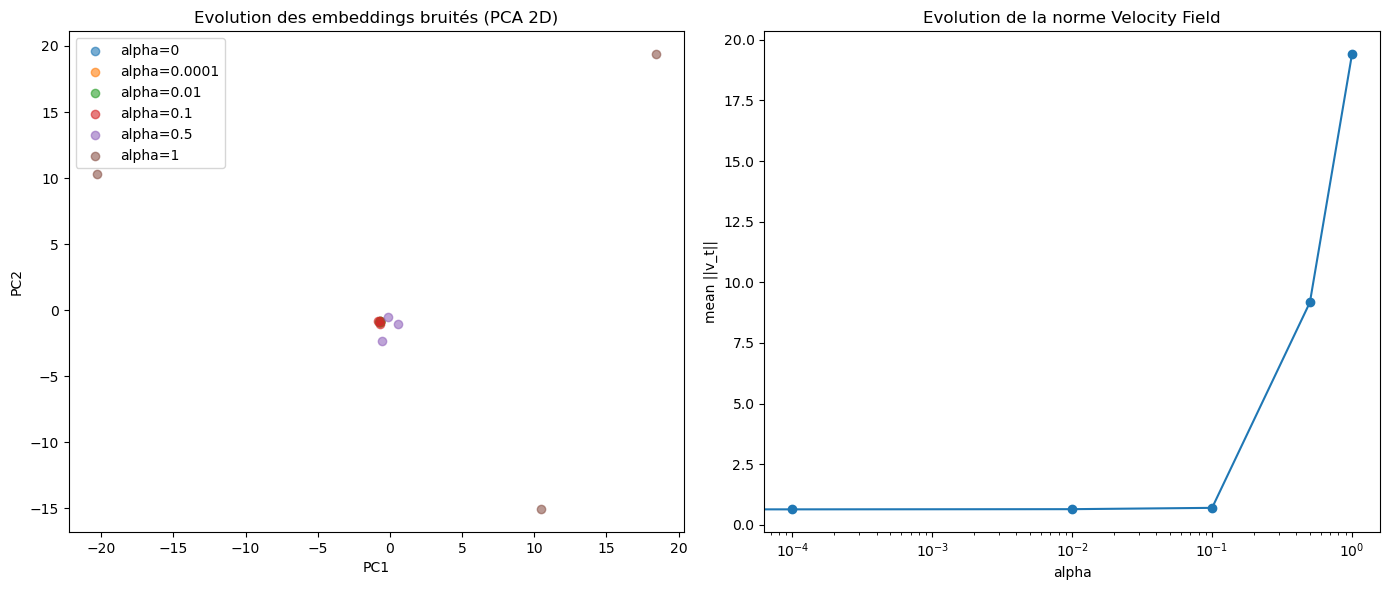

In [17]:
alpha_s = [0, 1e-4, 1e-2, 1e-1, 0.5, 1]

X = X_inlier[:3]
N, D = X.shape

all_points = []
liste_vt = []

t = torch.tensor([0.25], device=device).expand(N)

for alpha in alpha_s:
    
    noise = alpha * torch.randn_like(X).to(device)
    x_inlier_noised = X + noise
    
    v_t = fm_transformer.model(x_inlier_noised, t)
    mean_norm = torch.mean(torch.norm(v_t, dim=1)).item()
    liste_vt.append(mean_norm)
    
    all_points.append(x_inlier_noised.detach().cpu().numpy())

all_points = np.vstack(all_points)

pca = PCA(n_components=2)
points_2d = pca.fit_transform(all_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
start = 0
for alpha in alpha_s:
    end = start + N
    axes[0].scatter(
        points_2d[start:end, 0],
        points_2d[start:end, 1],
        label=f'alpha={alpha}',
        alpha=0.6
    )
    start = end

axes[0].set_title("Evolution des embeddings bruités (PCA 2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

axes[1].plot(alpha_s, liste_vt, marker='o')
axes[1].set_title("Evolution de la norme Velocity Field")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("mean ||v_t||")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import chi2

def belongs_to_gaussian_isotropic(x, mu, sigma, alpha=0.95):
    """
    x : shape (768,) or (n,768)
    mu : shape (768,)
    sigma : scalar (std)
    alpha : confidence level
    """
    x = np.atleast_2d(x)
    d = mu.shape[0]
    
    diff = x - mu
    maha_sq = np.sum(diff**2, axis=1) / (sigma**2)
    
    threshold = chi2.ppf(alpha, df=d)
    
    return maha_sq <= threshold

x = x_intermer_test_noise[-1][0].cpu().numpy()
belongs_to_gaussian_isotropic(x, fm_transformer.centroid.cpu().numpy(), fm_transformer.var.cpu().numpy(), alpha=0.95)

array([False])

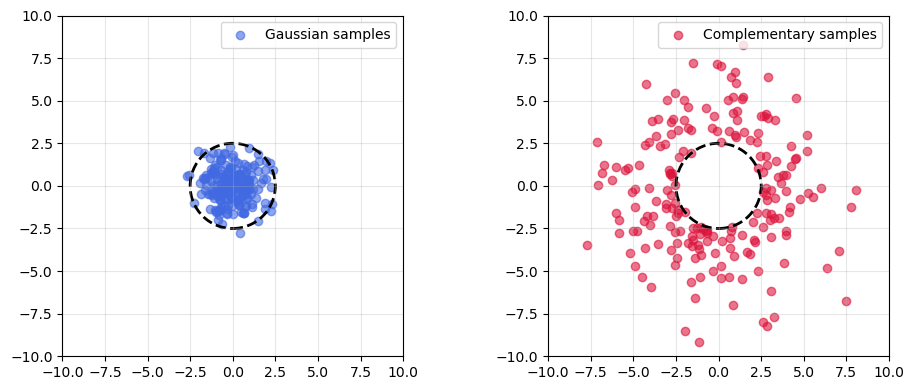

In [25]:
np.random.seed(0)
mu = np.array([0.0, 0.0])
sigma = 1.0
dim = 2
n_samples = 200
R = 2.5 * sigma

gaussian_samples = np.random.randn(n_samples, dim) * sigma + mu

complementary_samples = []

while len(complementary_samples) < n_samples:
    proposal = np.random.randn(n_samples, dim) * (3 * sigma) + mu
    distances = np.linalg.norm(proposal - mu, axis=1)
    accepted = proposal[distances > R]
    complementary_samples.extend(accepted)

complementary_samples = np.array(complementary_samples[:n_samples])


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ---- Gaussian ----
axes[0].scatter(
    gaussian_samples[:, 0],
    gaussian_samples[:, 1],
    color="royalblue",
    alpha=0.6,
    label="Gaussian samples"
)

circle1 = plt.Circle(mu, R, color="black", fill=False, linewidth=2, linestyle="--")
axes[0].add_patch(circle1)

# axes[0].set_title("Gaussian", fontsize=13)
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-10, 10)
axes[0].set_aspect("equal", "box")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- Complementary ----
axes[1].scatter(
    complementary_samples[:, 0],
    complementary_samples[:, 1],
    color="crimson",
    alpha=0.6,
    label="Complementary samples"
)

circle2 = plt.Circle(mu, R, color="black", fill=False, linewidth=2, linestyle="--")
axes[1].add_patch(circle2)

# axes[1].set_title("Complementary Distribution (Outside R)", fontsize=13)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(-10, 10)
axes[1].set_aspect("equal", "box")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

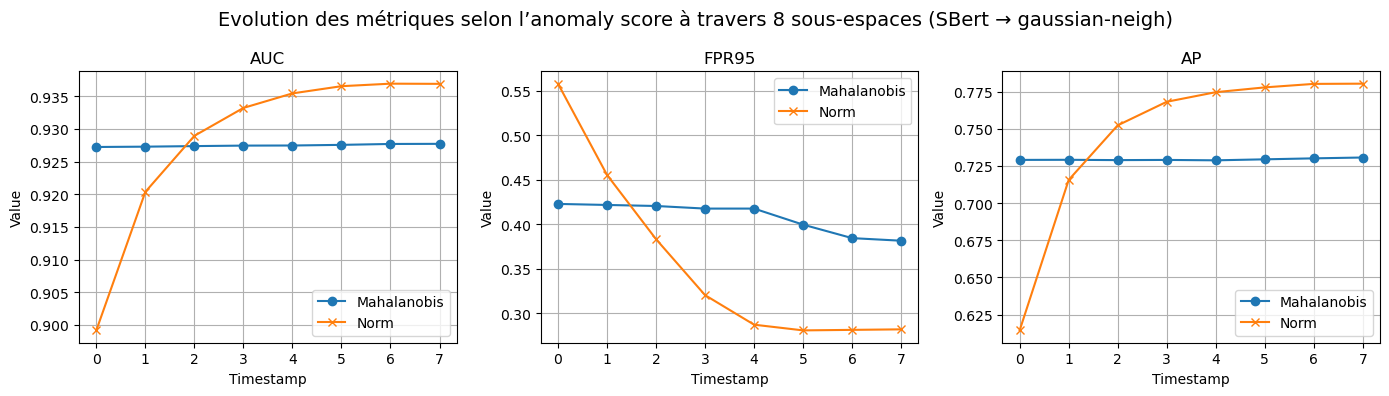

In [ ]:
metric_names = ["AUC", "FPR95", "AP"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i in range(3):
    axes[i].plot(metrics_history_maha[:, i], label="Mahalanobis", marker='o')
    axes[i].plot(metrics_history_norm[:, i], label="Norm", marker='x')
    axes[i].set_title(metric_names[i])
    axes[i].set_xlabel("Timestamp")
    axes[i].set_ylabel("Value")
    axes[i].legend()
    axes[i].grid(True)


fig.suptitle(
    f"Evolution des métriques selon l’anomaly score à travers {n_steps} sous-espaces ({naming_dis['source']} → {naming_dis['target']})",
    fontsize=14
)

plt.tight_layout()
plt.show()


In [ ]:
print(f" Mahalanobis : {np.mean(metrics_history_maha, axis=0)}, {np.std(metrics_history_maha, axis=0)}")
print(f" Norm : {np.mean(metrics_history_norm, axis=0)}, {np.std(metrics_history_norm, axis=0)}")

 Mahalanobis : [0.92729287 0.42561082 0.72855475], [3.57202543e-05 1.48135172e-03 2.99285426e-04]
 Norm : [0.92402407 0.43200989 0.72993957], [0.01075703 0.05558672 0.05088856]


Epoch 0: CD loss = -1.4979


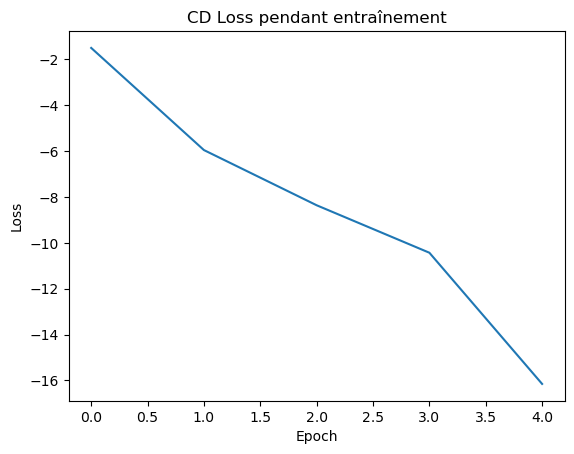

In [ ]:
class EBM(nn.Module):
    def __init__(self, input_dim=2, dim_hid=64):
        super().__init__()
        self.dim_hid = dim_hid
        self.input_dim = input_dim
        self.net = nn.Sequential(
            nn.Linear(self.input_dim, self.dim_hid),
            nn.ReLU(),
            nn.Linear(self.dim_hid, self.dim_hid),
            nn.ReLU(),
            nn.Linear(self.dim_hid, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = EBM(x_intermer_inlier_noise[1].shape[1], 64).to(device)

lr = 1e-3
batch_size = 64
epochs = 5
K = 10            # Langevin steps
eta = 1e-1        # step size Langevin
eps = 0.05        # bruit Langevin
optimizer = optim.Adam(model.parameters(), lr=lr)

def langevin_samples(x_init, model, K=20, eta=0.1, eps=0.01):
    x = x_init.clone().detach()
    x.requires_grad_(True)
    for _ in range(K):
        energy = model(x)
        grad = torch.autograd.grad(energy.sum(), x)[0]
        x.data -= eta * grad + torch.randn_like(x) * np.sqrt(2*eta*eps)
    return x.detach()

# data_loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
X_inlier_dl = DataLoader(TensorDataset(x_intermer_inlier_noise[1]), batch_size=batch_size, shuffle=True)

loss_history = []
for epoch in range(epochs):
    for x_batch, in X_inlier_dl:
        noise = torch.randn_like(x_batch)
        x_neg_init = torch.cat([x_batch, noise], dim=0)
        x_neg = langevin_samples(x_neg_init, model, K=K, eta=eta, eps=eps)

        energy_pos = model(x_batch)
        energy_neg = model(x_neg)
        loss = (energy_pos.mean() - energy_neg.mean())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    loss_history.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: CD loss = {loss.item():.4f}")

plt.plot(loss_history)
plt.title("CD Loss pendant entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [135]:
ev.evaluation(y_test, model(x_intermer_test_noise[1]).cpu().detach().numpy())

AUC:        0.8956
Avg Precision: 0.5872
FPR@95:     0.5538


(0.8956125042099139, 0.5538103548574753, 0.5872432860297337)

## Basic FM

In [386]:
from Modelisation.FlowMatching.flow_matching import BasicFlowMatching

file_path_hyp = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/hyperparams.txt"
hyp = load_hyperparams(dataset_name, inlier_topic, 'sentence_bert', file_path_hyp)
print(f" {hyp['source']} - {hyp['target']}")

 sphere-noised - torch.Size([1437, 384])


In [387]:
fm_args = {
    "batch_size": hyp["batch_size"],
    "input_dim": X_inlier.shape[1],
    "latent_dim": hyp["latent_dim"],
    "sinu": False,
    "batchnorm": False,
    "dropout": hyp["dropout"],
    "lr": hyp["lr"],
    "weight_decay": hyp["weight_decay"],
    "n_epochs": hyp["n_epochs"],
    # "n_epochs": 500,
    "target": X_inlier.cpu(),
    "source": hyp["source"],
    # "source": 'point-mean',
    "device": device,
    "score_type" : "norm",
    "solver_type" : "midpoint",
    "n_steps": 10, 
    "noise_is_target": False
}

naming_dis = {
    'target' : fm_args['source'] if fm_args['noise_is_target'] else 'SBert', 
    'source' : fm_args['source'] if not fm_args['noise_is_target'] else 'SBert'
}

fm_model = BasicFlowMatching(fm_args)
_ = fm_model.train(X_inlier)
auc_fm, fpr95_fm, ap_fm = fm_model.test(X_test, y_test)
print(f"FM --> AUC: {auc_fm:.4f} | FPR@95: {fpr95_fm:.4f} | AP: {ap_fm:.4f}\n")

FM --> AUC: 0.9695 | FPR@95: 0.1503 | AP: 0.8478



In [388]:
n_steps = 8
x_intermer_test_noise = fm_model.fm_trainer.backward_flow(X_test,'midpoint',n_steps)
x_intermer_inlier_noise = fm_model.fm_trainer.backward_flow(X_inlier,'midpoint',n_steps)

In [389]:
metrics_history_maha = []
metrics_history_norm = []

for num_repre_space in range(n_steps):

    ############## MANALANOBIS ####################
    x_1_inliers = x_intermer_inlier_noise[num_repre_space].cpu().numpy()

    mean_inlier = np.mean(x_1_inliers, axis=0)
    cov_inlier = np.cov(x_1_inliers.T)
    cov_inlier += 1e-6 * np.eye(cov_inlier.shape[0])

    diff = x_intermer_test_noise[num_repre_space].cpu().numpy() - mean_inlier
    inv_cov = np.linalg.inv(cov_inlier)

    scores = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))
    metrics_history_maha.append(ev.evaluation(y_test, scores, verbose=False))

    ################### NORM ########################
    scores = np.sum(x_intermer_test_noise[num_repre_space].cpu().numpy() ** 2, axis=1)
    metrics_history_norm.append(ev.evaluation(y_test, scores, verbose=False))

metrics_history_maha = np.array(metrics_history_maha)
metrics_history_norm = np.array(metrics_history_norm)

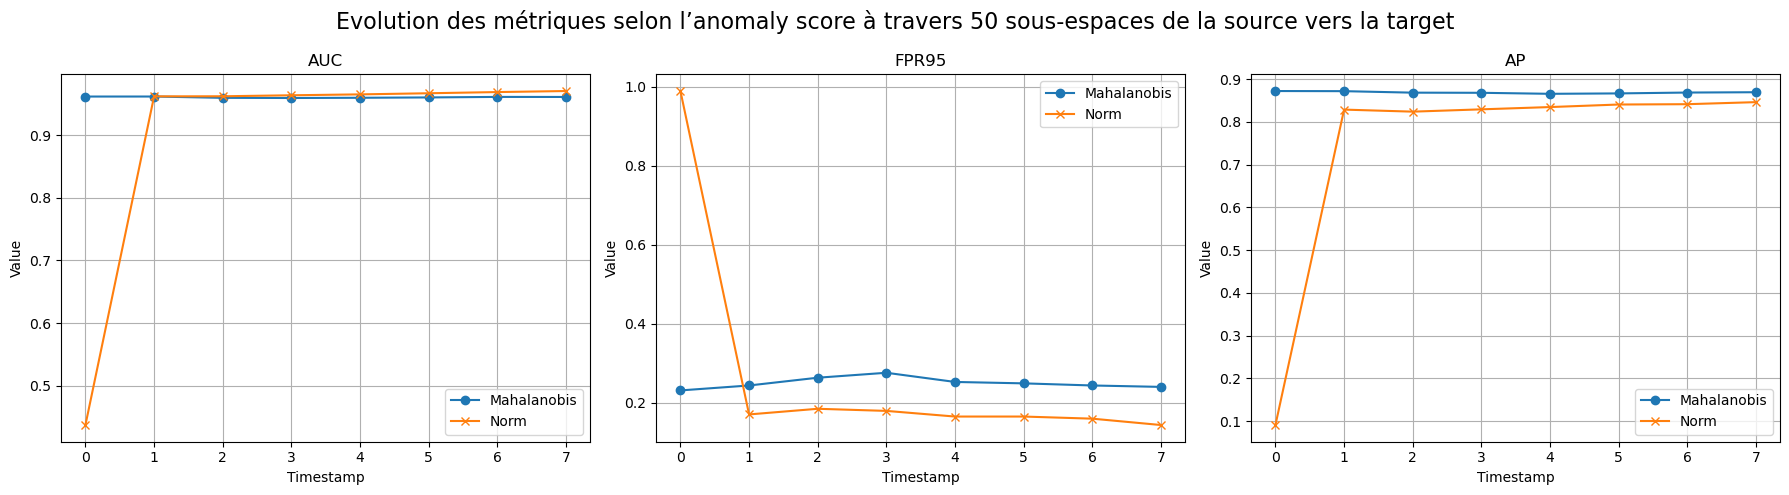

In [390]:
metric_names = ["AUC", "FPR95", "AP"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for i in range(3):
    axes[i].plot(metrics_history_maha[:, i], label="Mahalanobis", marker='o')
    axes[i].plot(metrics_history_norm[:, i], label="Norm", marker='x')
    axes[i].set_title(metric_names[i])
    axes[i].set_xlabel("Timestamp")
    axes[i].set_ylabel("Value")
    axes[i].legend()
    axes[i].grid(True)


fig.suptitle(
    "Evolution des métriques selon l’anomaly score à travers 50 sous-espaces de la source vers la target",
    fontsize=16
)

plt.tight_layout()
plt.show()


In [391]:
X_np = x_intermer_test_noise.detach().cpu().numpy()

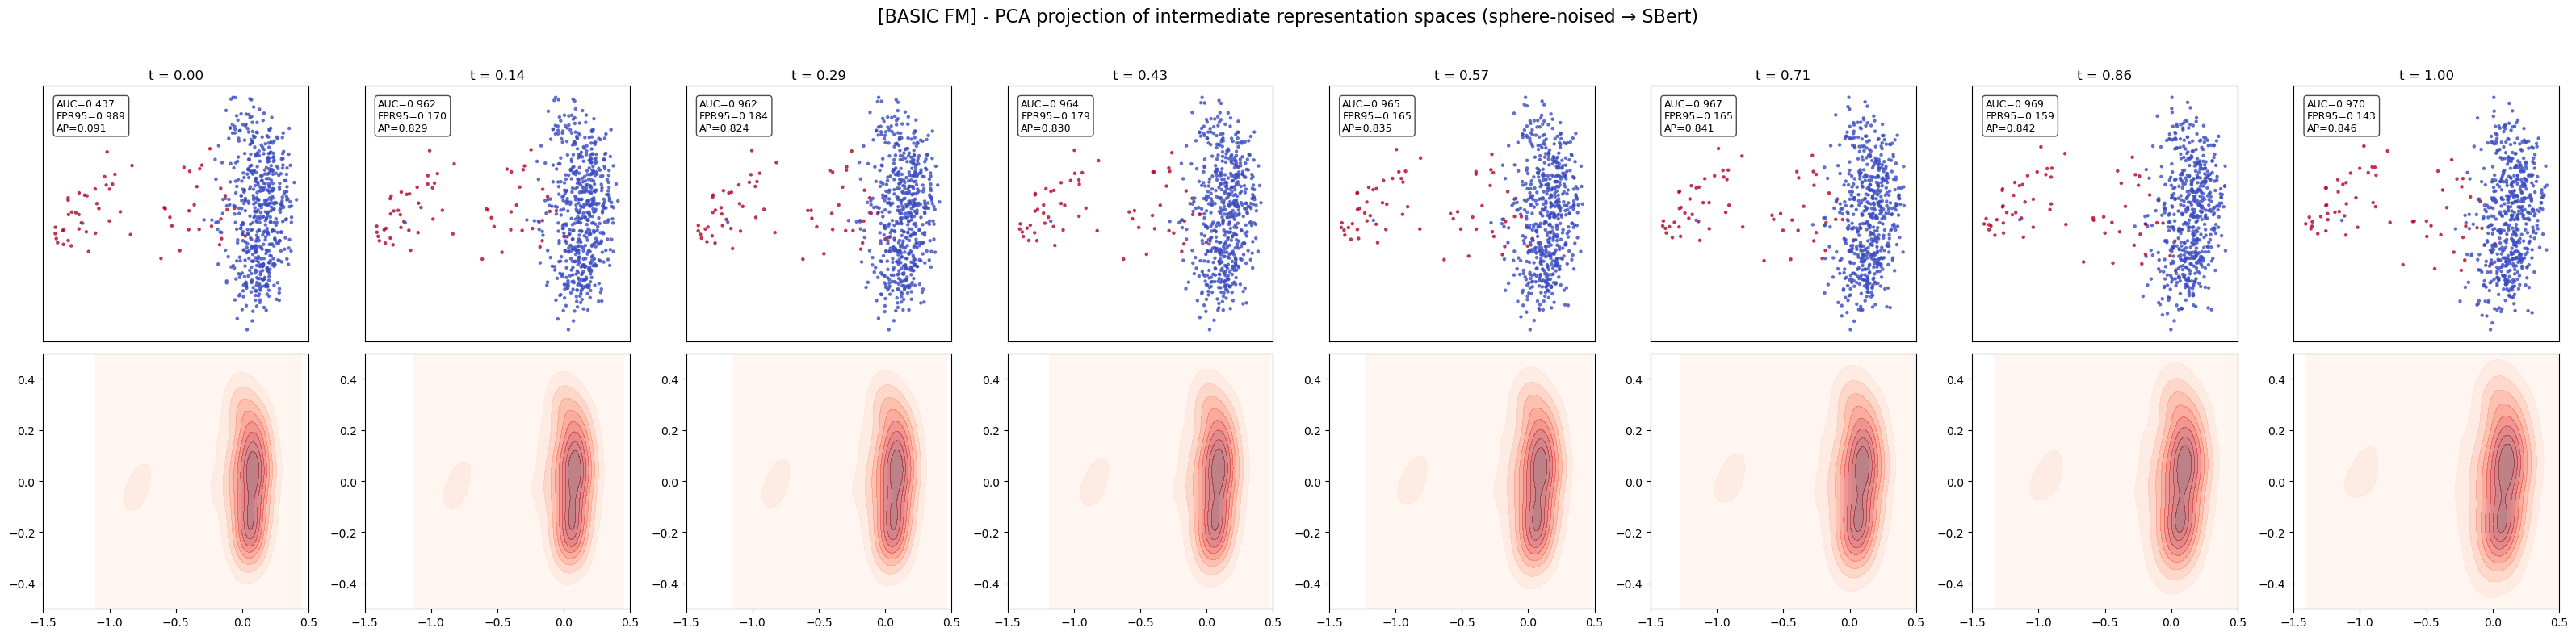

In [392]:
X_np = x_intermer_test_noise.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_steps):
        if algo_name == "t-SNE":
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            c=y_test,
            cmap="coolwarm",
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])

        ax_scatter.text(
            0.05, 0.95,
            f"AUC={metrics_history_norm[i][0]:.3f}\n"
            f"FPR95={metrics_history_norm[i][1]:.3f}\n"
            f"AP={metrics_history_norm[i][2]:.3f}",
            transform=ax_scatter.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        )
        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(-1.5, 0.5) 
        ax_kde.set_ylim(-0.5, 0.5)

    fig.suptitle(
        f"[BASIC FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

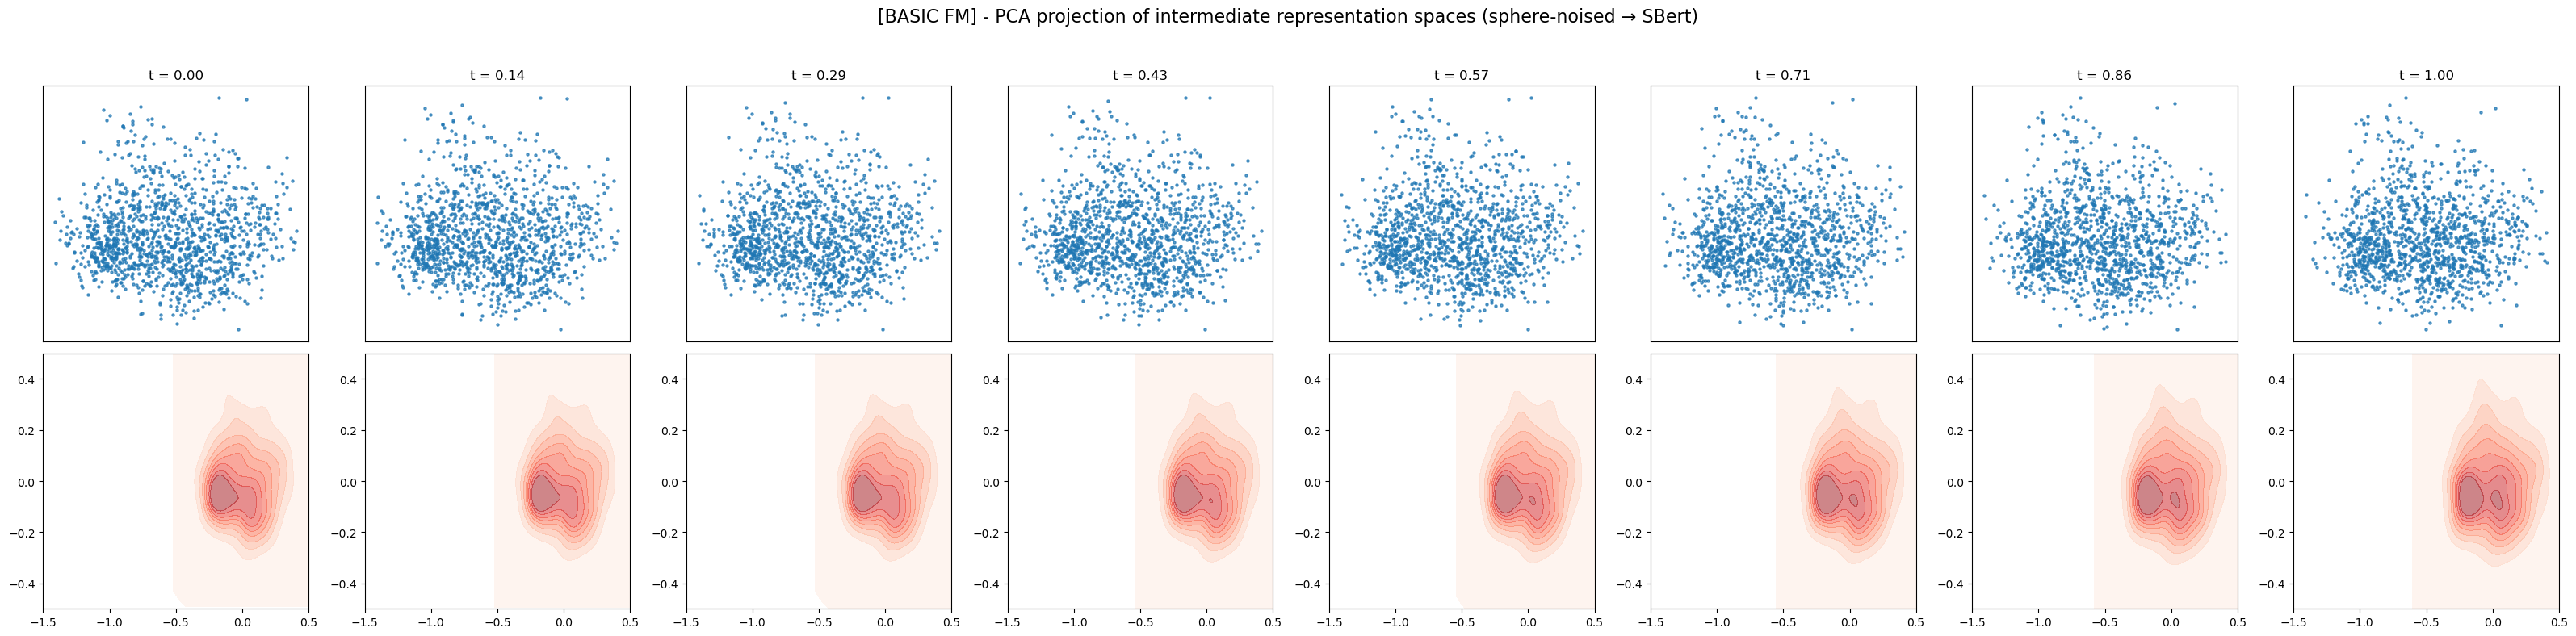

In [393]:
X_np = x_intermer_inlier_noise.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_steps):
        if algo_name == "t-SNE":
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])

        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(-1.5, 0.5) 
        ax_kde.set_ylim(-0.5, 0.5)

    fig.suptitle(
        f"[BASIC FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Epoch 0: CD loss = -0.5612


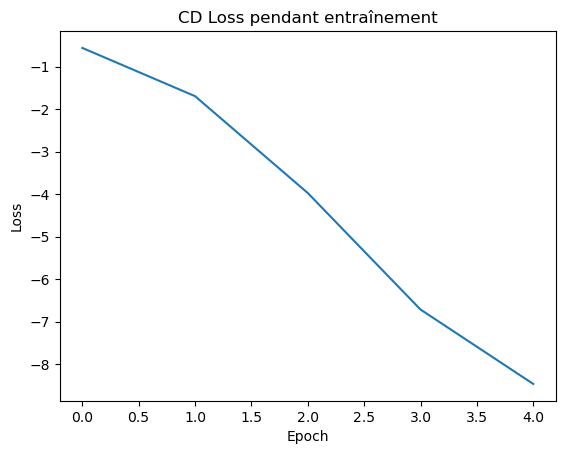

In [263]:
class EBM(nn.Module):
    def __init__(self, input_dim=2, dim_hid=64):
        super().__init__()
        self.dim_hid = dim_hid
        self.input_dim = input_dim
        self.net = nn.Sequential(
            nn.Linear(self.input_dim, self.dim_hid),
            nn.ReLU(),
            nn.Linear(self.dim_hid, self.dim_hid),
            nn.ReLU(),
            nn.Linear(self.dim_hid, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = EBM(x_intermer_inlier_noise[-1].shape[1], 64).to(device)

lr = 1e-3
batch_size = 64
epochs = 5
K = 10            # Langevin steps
eta = 1e-1        # step size Langevin
eps = 0.05        # bruit Langevin
optimizer = optim.Adam(model.parameters(), lr=lr)

def langevin_samples(x_init, model, K=20, eta=0.1, eps=0.01):
    x = x_init.clone().detach()
    x.requires_grad_(True)
    for _ in range(K):
        energy = model(x)
        grad = torch.autograd.grad(energy.sum(), x)[0]
        x.data -= eta * grad + torch.randn_like(x) * np.sqrt(2*eta*eps)
    return x.detach()

# data_loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
X_inlier_dl = DataLoader(TensorDataset(x_intermer_inlier_noise[-1]), batch_size=batch_size, shuffle=True)

loss_history = []
for epoch in range(epochs):
    for x_batch, in X_inlier_dl:
        noise = torch.randn_like(x_batch)
        x_neg_init = torch.cat([x_batch, noise], dim=0)
        x_neg = langevin_samples(x_neg_init, model, K=K, eta=eta, eps=eps)

        energy_pos = model(x_batch)
        energy_neg = model(x_neg)
        loss = (energy_pos.mean() - energy_neg.mean())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    loss_history.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: CD loss = {loss.item():.4f}")

plt.plot(loss_history)
plt.title("CD Loss pendant entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [303]:
ev.evaluation(y_test, model(x_intermer_test_noise[-1]).cpu().detach().numpy())

AUC:        0.8996
Avg Precision: 0.6133
FPR@95:     0.4154


(0.8995958482593919, 0.41535776614310643, 0.6132716639197288)

## Masking

In [25]:
import numpy as np
import random
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def random_mask(text, mask_token="[MASK]", mask_prob=0.15):
    words = text.split()
    masked_words = [
        mask_token if random.random() < mask_prob else w
        for w in words
    ]
    return " ".join(masked_words)

def exact_mask(text, mask_token="[MASK]", mask_ratio=0.15, seed=None):
    words = text.split()
    n_tokens = len(words)
    
    if n_tokens == 0:
        return text
    
    if seed is not None:
        random.seed(seed)
    
    n_to_mask = max(1, math.floor(mask_ratio * n_tokens))
    mask_indices = random.sample(range(n_tokens), n_to_mask)
    
    masked_words = [
        mask_token if i in mask_indices else w
        for i, w in enumerate(words)
    ]
    
    return " ".join(masked_words)

In [60]:
texts = data_test['text']
labels = data_test['anomaly_class']  # 0 / 1

mask_ratio = 0.1

texts_masked = [
    exact_mask(t, mask_ratio=mask_ratio)
    for t in texts
]

model = SentenceTransformer('all-distilroberta-v1')

emb_normal = model.encode(texts, batch_size=32, show_progress_bar=True)
emb_masked = model.encode(texts_masked, batch_size=32, show_progress_bar=True)

emb_all = np.vstack([emb_normal, emb_masked])
N = len(emb_normal)

# ---------- PCA ----------
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(emb_all)

pca_normal = emb_pca[:N]
pca_masked = emb_pca[N:]

# ---------- t-SNE ----------
tsne = TSNE(n_components=2,
            perplexity=30,
            learning_rate=200,
            max_iter=1000,
            random_state=42)

emb_tsne = tsne.fit_transform(emb_all)

tsne_normal = emb_tsne[:N]
tsne_masked = emb_tsne[N:]

# Indices
idx_inlier = np.array(labels) == 0
idx_anomaly = np.array(labels) == 1


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

Batches:   0%|          | 0/60 [00:00<?, ?it/s]

In [61]:
idx_inlier = np.array(labels) == 0
idx_anomaly = np.array(labels) == 1

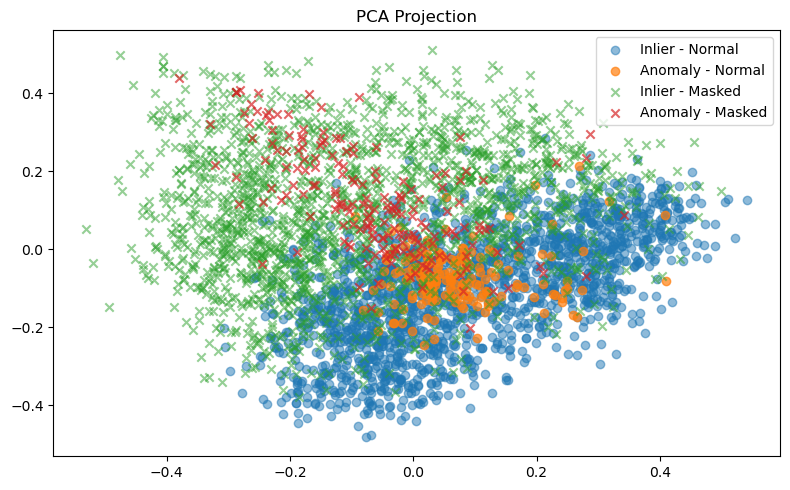

In [62]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.scatter(
    pca_normal[idx_inlier, 0], pca_normal[idx_inlier, 1],
    alpha=0.5, label="Inlier - Normal"
)

axes.scatter(
    pca_normal[idx_anomaly, 0], pca_normal[idx_anomaly, 1],
    alpha=0.7, label="Anomaly - Normal"
)

axes.scatter(
    pca_masked[idx_inlier, 0], pca_masked[idx_inlier, 1],
    alpha=0.5, marker='x', label="Inlier - Masked"
)

axes.scatter(
    pca_masked[idx_anomaly, 0], pca_masked[idx_anomaly, 1],
    alpha=0.7, marker='x', label="Anomaly - Masked"
)

axes.set_title("PCA Projection")
axes.legend()

plt.tight_layout()
plt.show()

In [63]:
cos_sim = np.mean(np.sum(
    emb_normal[idx_inlier] * emb_masked[idx_inlier], axis=1
) / (
    np.linalg.norm(emb_normal[idx_inlier], axis=1) *
    np.linalg.norm(emb_masked[idx_inlier], axis=1)
))

print("Mean cosine similarity:", cos_sim)

Mean cosine similarity: 0.8654402


In [64]:
cos_sim = np.mean(np.sum(
    emb_normal[idx_anomaly] * emb_masked[idx_anomaly], axis=1
) / (
    np.linalg.norm(emb_normal[idx_anomaly], axis=1) *
    np.linalg.norm(emb_masked[idx_anomaly], axis=1)
))

print("Mean cosine similarity:", cos_sim)

Mean cosine similarity: 0.84840745


In [65]:
mask_ratio = 0.3
texts_masked = [
    exact_mask(t, mask_ratio=mask_ratio)
    for t in data_train['text']
]

sb_model = SentenceTransformer('all-distilroberta-v1')
X_inlier_masked = sb_model.encode(texts_masked, batch_size=32, show_progress_bar=True)

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

In [121]:
config = {
        'latent_dim': 768,
        'hidden_dim': 64,
        'depth': 2,
        'n_heads': 2,
        'lr': 1e-3,
        'weight_decay': 1e-5,
        'epochs': 100,
        'warmup_epochs': 5,
        'grad_clip': 1.0,
        'flow_type': 'linear',  
        'sigma': 0.1, 
        'batch_size' : 64,
        'lambda_reg_angle': None,
        'target' : 'gaussian-neigh',
        # 'target' : Tensor(X_inlier_masked).to(device),
        'source' : X_inlier.to(device)
        # 'source' : torch.concatenate((X_inlier.to(device), torch.randn(100, X_inlier.shape[1]).to(device)))
        # 'source' : X_inlier + torch.randn_like(X_inlier).to(device)
        # 'source' : torch.concatenate([X_inlier, X_anom_for_train]).to(device)   
}
noise_is_target = True
naming_dis = {
    'target' : config['target'] if noise_is_target else 'SBert', 
    'source' : config['source'] if not noise_is_target else 'SBert'
}

flowmodel = FlowDiT(
                latent_dim=config['latent_dim'],
                hidden_dim=config['hidden_dim'],
                depth=config['depth'],
                n_heads=config['n_heads']
        ).to(device)

fm_transformer = FlowMatchingTransformers(flowmodel, config['source'], config['target'], config, noise_is_target=noise_is_target, rectified=None)
liste_loss, liste_loss_regul = fm_transformer.train(X_inlier, True)

18.90509456518609

Epoch 1/100
Train Loss: 0.0154, LR: 0.000200
11.703181859255476
11.539862848065939
11.556590501658048
11.795920405466433
11.938150799810021
12.172439949943847
12.334425416270932
12.5358881429136
12.685744368728242
12.729409279066964
12.919607929685519
12.963850712867163
13.055220480311776
13.063082736570994
12.99882850093156
13.124138996057857
13.22046616244153
13.224547294173796
13.392405632386009
13.135856793258602
13.60922569378043
13.406344366637748
13.530481020906064
13.315873846658567
13.460716968523819
13.576273397137339
13.66434334471546
13.769065430314244
13.808538404033726
13.985625672538424
13.937051839617231
14.108764063728472
13.95980800497732

Epoch 34/100
Train Loss: 0.0105, LR: 0.000801
13.783395718176214
14.035506212407306
13.552967919722901
13.7779298655907
13.888914752591218
14.231985730553868
13.838212859285164
14.025845518471531
14.319879654546927
13.703374268830075
13.626186382113884
13.947386627853747
13.949379087371272
13.944736442976902
13.55

In [107]:
scores = fm_transformer.test(X_test, y_test, X_inlier, 'norm-centroid')
print(scores)

(0.9261351458926549, 0.4432809773123909, 0.7251898051515596)


In [108]:
n_steps = 8
x_intermer_test_noise = fm_transformer.forward_flow(X_test,'midpoint',n_steps)
x_intermer_inlier_noise = fm_transformer.forward_flow(X_inlier,'midpoint',n_steps)
metrics_history_maha = []
metrics_history_norm = []

for num_repre_space in range(n_steps):

    ############## MANALANOBIS ####################

    x_1_inliers = x_intermer_inlier_noise[num_repre_space].cpu().numpy()

    mean_inlier = np.mean(x_1_inliers, axis=0)
    cov_inlier = np.cov(x_1_inliers.T)
    cov_inlier += 1e-6 * np.eye(cov_inlier.shape[0])

    diff = x_intermer_test_noise[num_repre_space].cpu().numpy() - mean_inlier
    inv_cov = np.linalg.inv(cov_inlier)

    scores = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))
    metrics_history_maha.append(ev.evaluation(y_test, scores, verbose=False))


    ################### NORM ########################

    scores = np.sum(x_intermer_test_noise[num_repre_space].cpu().numpy() ** 2, axis=1)
    # scores = np.sum((x_intermer_test_noise[num_repre_space].cpu().numpy() - fm_transformer.centroid.repeat(x_intermer_test_noise[num_repre_space].cpu().numpy().shape[0],1).cpu().numpy()) ** 2, axis=1)
    metrics_history_norm.append(ev.evaluation(y_test, scores, verbose=False))


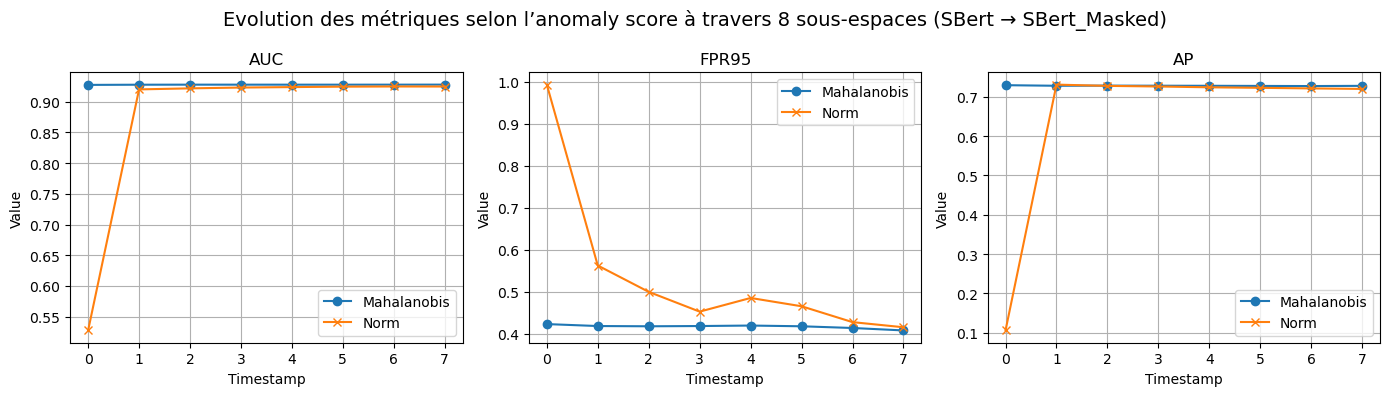

In [109]:
metrics_history_maha = np.array(metrics_history_maha)
metrics_history_norm = np.array(metrics_history_norm)
metric_names = ["AUC", "FPR95", "AP"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i in range(3):
    axes[i].plot(metrics_history_maha[:, i], label="Mahalanobis", marker='o')
    axes[i].plot(metrics_history_norm[:, i], label="Norm", marker='x')
    axes[i].set_title(metric_names[i])
    axes[i].set_xlabel("Timestamp")
    axes[i].set_ylabel("Value")
    axes[i].legend()
    axes[i].grid(True)


fig.suptitle(
    # f"Evolution des métriques selon l’anomaly score à travers {n_steps} sous-espaces ({naming_dis['source']} → {naming_dis['target']})",
    f"Evolution des métriques selon l’anomaly score à travers {n_steps} sous-espaces ({naming_dis['source']} → SBert_Masked)",
    fontsize=14
)

plt.tight_layout()
plt.show()

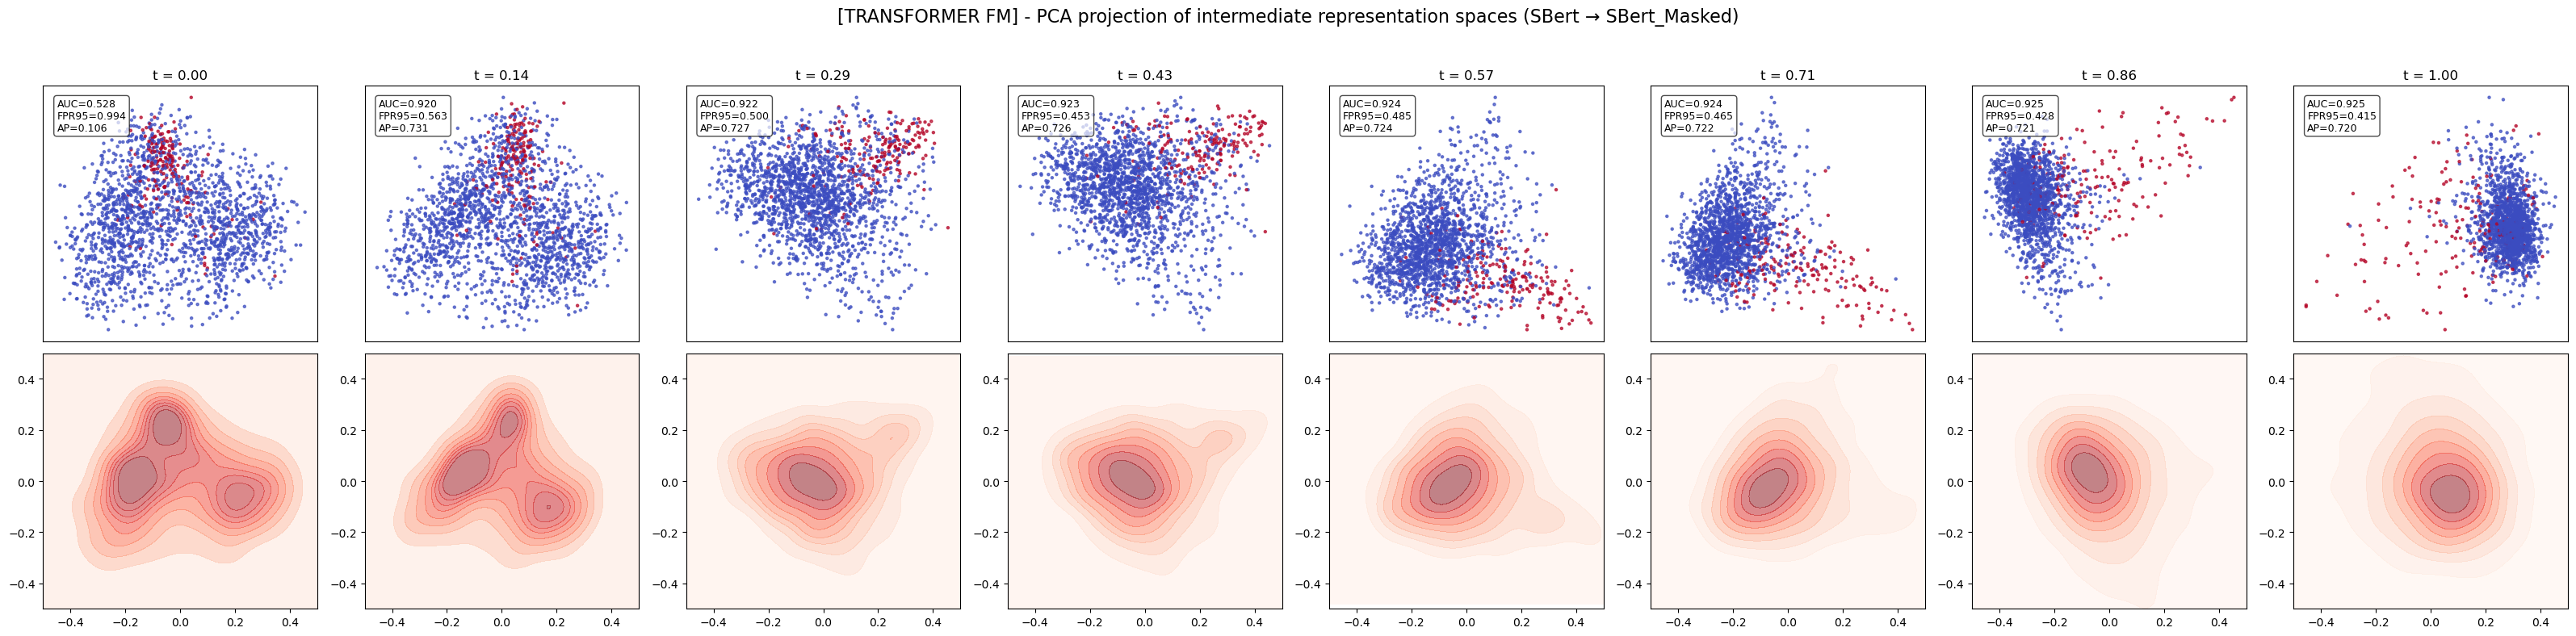

In [110]:
X_np = x_intermer_test_noise.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_steps):
        if algo_name == "t-SNE":
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            c=y_test,
            cmap="coolwarm",
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])

        ax_scatter.text(
            0.05, 0.95,
            f"AUC={metrics_history_norm[i][0]:.3f}\n"
            f"FPR95={metrics_history_norm[i][1]:.3f}\n"
            f"AP={metrics_history_norm[i][2]:.3f}",
            transform=ax_scatter.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        )
        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(-0.5, 0.5) 
        ax_kde.set_ylim(-0.5, 0.5)

    fig.suptitle(
        # f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → SBert_Masked)",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

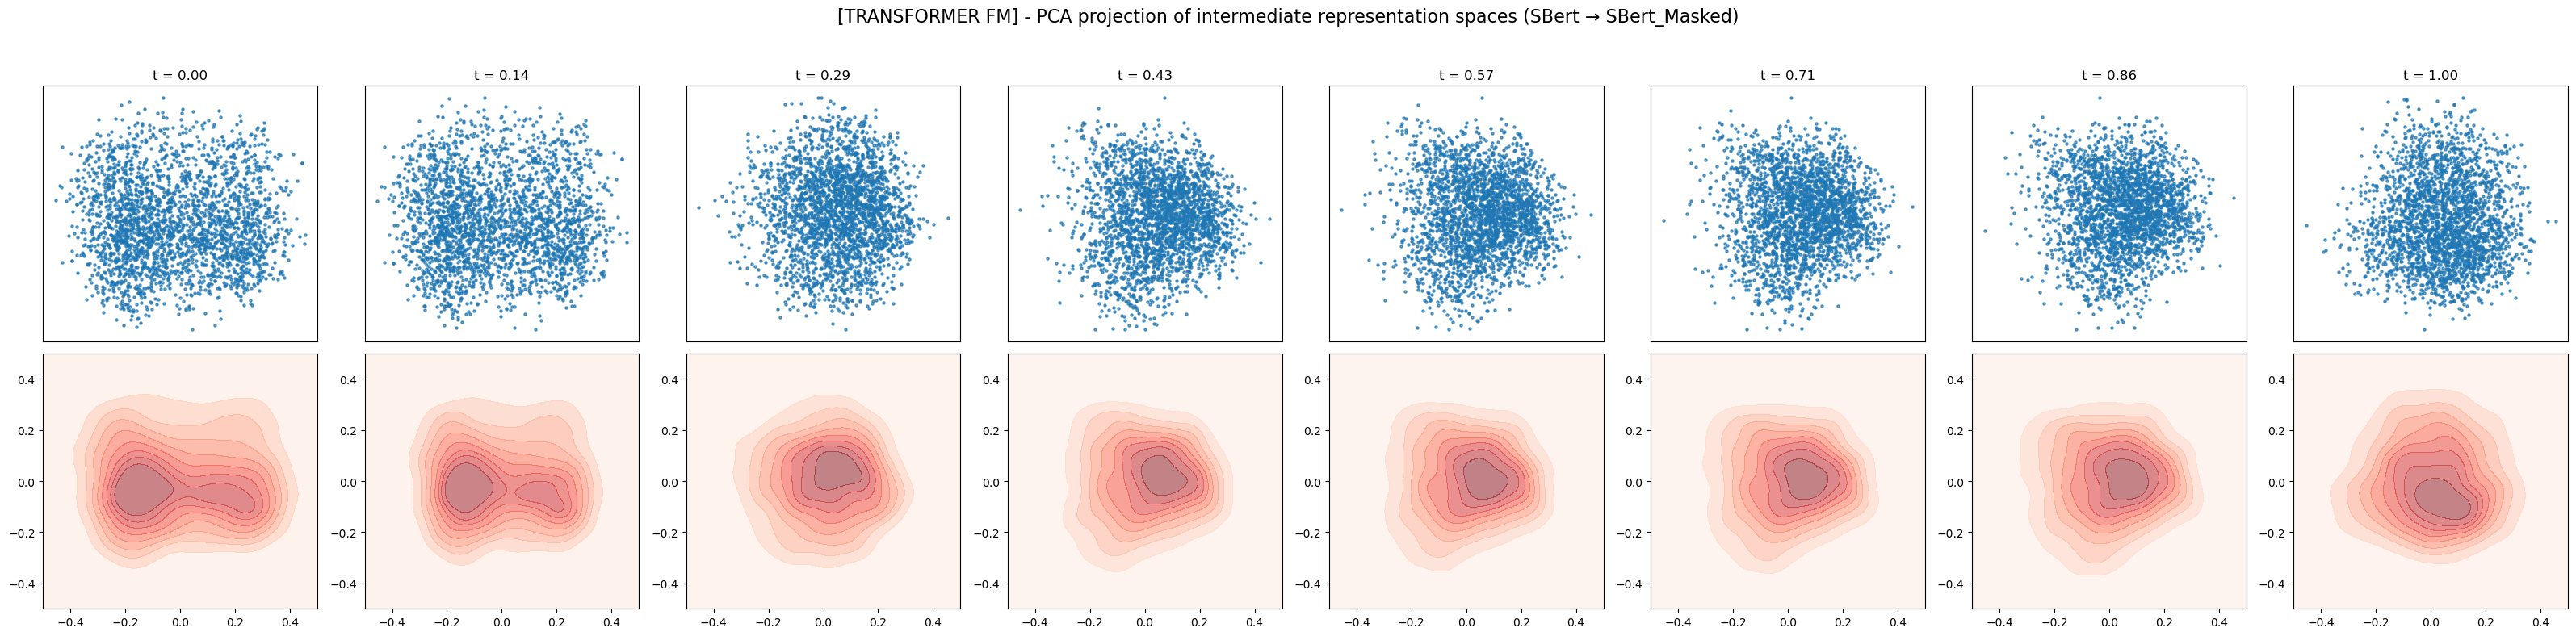

In [111]:
X_np = x_intermer_inlier_noise.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_steps):
        if algo_name == "t-SNE":
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])

        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(-0.5, 0.5) 
        ax_kde.set_ylim(-0.5, 0.5)

    fig.suptitle(
        # f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → SBert_Masked)",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()